In [ ]:
library(tidyverse)
library(corrplot)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Duomenys

In [3]:
data <- read.csv(file.path("..", "..", "python", "datasets_prep", "dm_project_dataset_alpha.csv"), sep = ',')
data$time <- as.Date(data$time) 
dim(data)

[1] 2772   31

In [4]:
head(data, 5)

,time,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,⋯,O3_Error,dust,sia,pm2p5,pans,nmvoc,nh3,pm10,tp,t2m
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-07-01,11.29583,1010.638,72.79167,9.100000e+00,89.37500,10.93333,3.762500,13.9,356,⋯,0.8230156,0.01145233,0.4123398,1.127883,1.174715,2.292138,0.1059741,1.338105,14.6533580000,12.97028
2,2018-07-02,10.86667,1006.663,94.00000,1.190000e+01,91.50000,10.42917,2.516667,7.0,327,⋯,0.7565302,0.01151537,0.9462600,1.609913,1.935448,3.792921,0.1984277,1.752331,6.4759570000,14.77985
3,2018-07-03,13.38750,1008.454,90.04167,1.000000e+01,89.37500,13.38750,2.537500,8.3,271,⋯,1.6245888,0.04419387,0.6769881,1.534471,1.787800,2.332084,0.1188589,1.789138,9.6073170000,15.96597
4,2018-07-04,13.59167,1009.237,88.29167,1.390000e+01,88.33333,13.59167,2.358333,8.7,288,⋯,0.7592764,0.12872760,0.8331606,3.229130,1.201320,2.113538,0.3611570,4.323638,0.0133075710,18.01572
5,2018-07-05,16.29167,1008.079,70.20833,2.220446e-16,66.00000,16.29167,1.283333,6.1,293,⋯,0.8920967,0.09764995,0.7374821,2.768797,1.206750,2.267631,0.3165334,3.718909,-0.0007406473,19.04031


In [5]:
colnames(data)

[1] "time"                                   
 [2] "airTemperature"                         
 [3] "seaLevelPressure"                       
 [4] "relativeHumidity"                       
 [5] "xgb_precipitation"                      
 [6] "xgb_cloudCover"                         
 [7] "feelsLikeTemperature_fixed"             
 [8] "windSpeed_fixed"                        
 [9] "windGust_fixed"                         
[10] "windDirection_fixed"                    
[11] "absorbing_aerosol_index"                
[12] "NO2_column_number_density"              
[13] "stratospheric_NO2_column_number_density"
[14] "NO2_slant_column_number_density"        
[15] "tropopause_pressure"                    
[16] "H2O_column_number_density"              
[17] "BrO"                                    
[18] "BrO_Error"                              
[19] "NO2"                                    
[20] "NO2_Error"                              
[21] "O3"                                     
[22] "O3_Error"                               
[23] "dust"                                   
[24] "sia"                                    
[25] "pm2p5"                                  
[26] "pans"                                   
[27] "nmvoc"                                  
[28] "nh3"                                    
[29] "pm10"                                   
[30] "tp"                                     
[31] "t2m"

In [6]:
data_clean <- data %>%
    select(-c('BrO_Error', 'NO2_Error', 'O3_Error'))

In [7]:
dim(data_clean)

[1] 2772   28

## Stacionarumas

### Sezoniškumas ir trendas

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 5, repr.plot.res = 200)

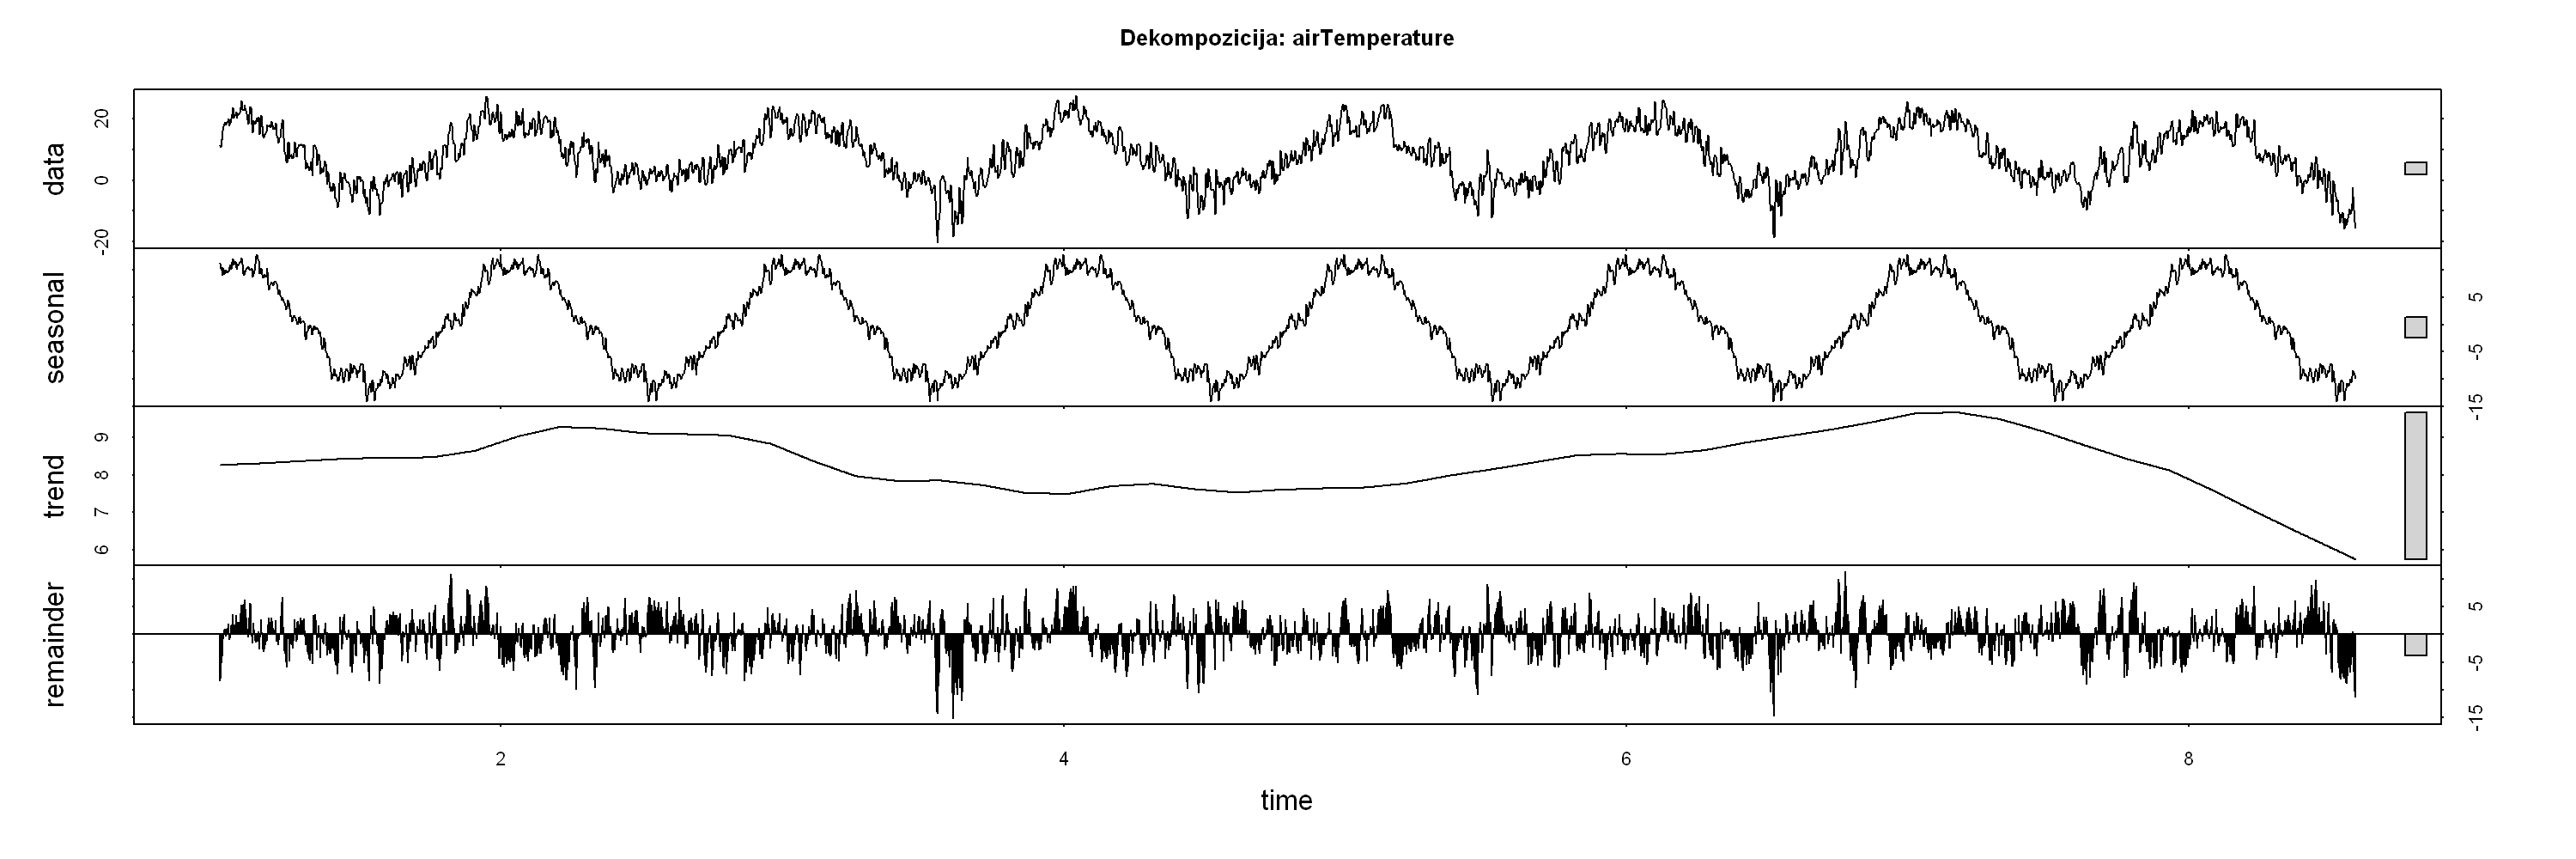

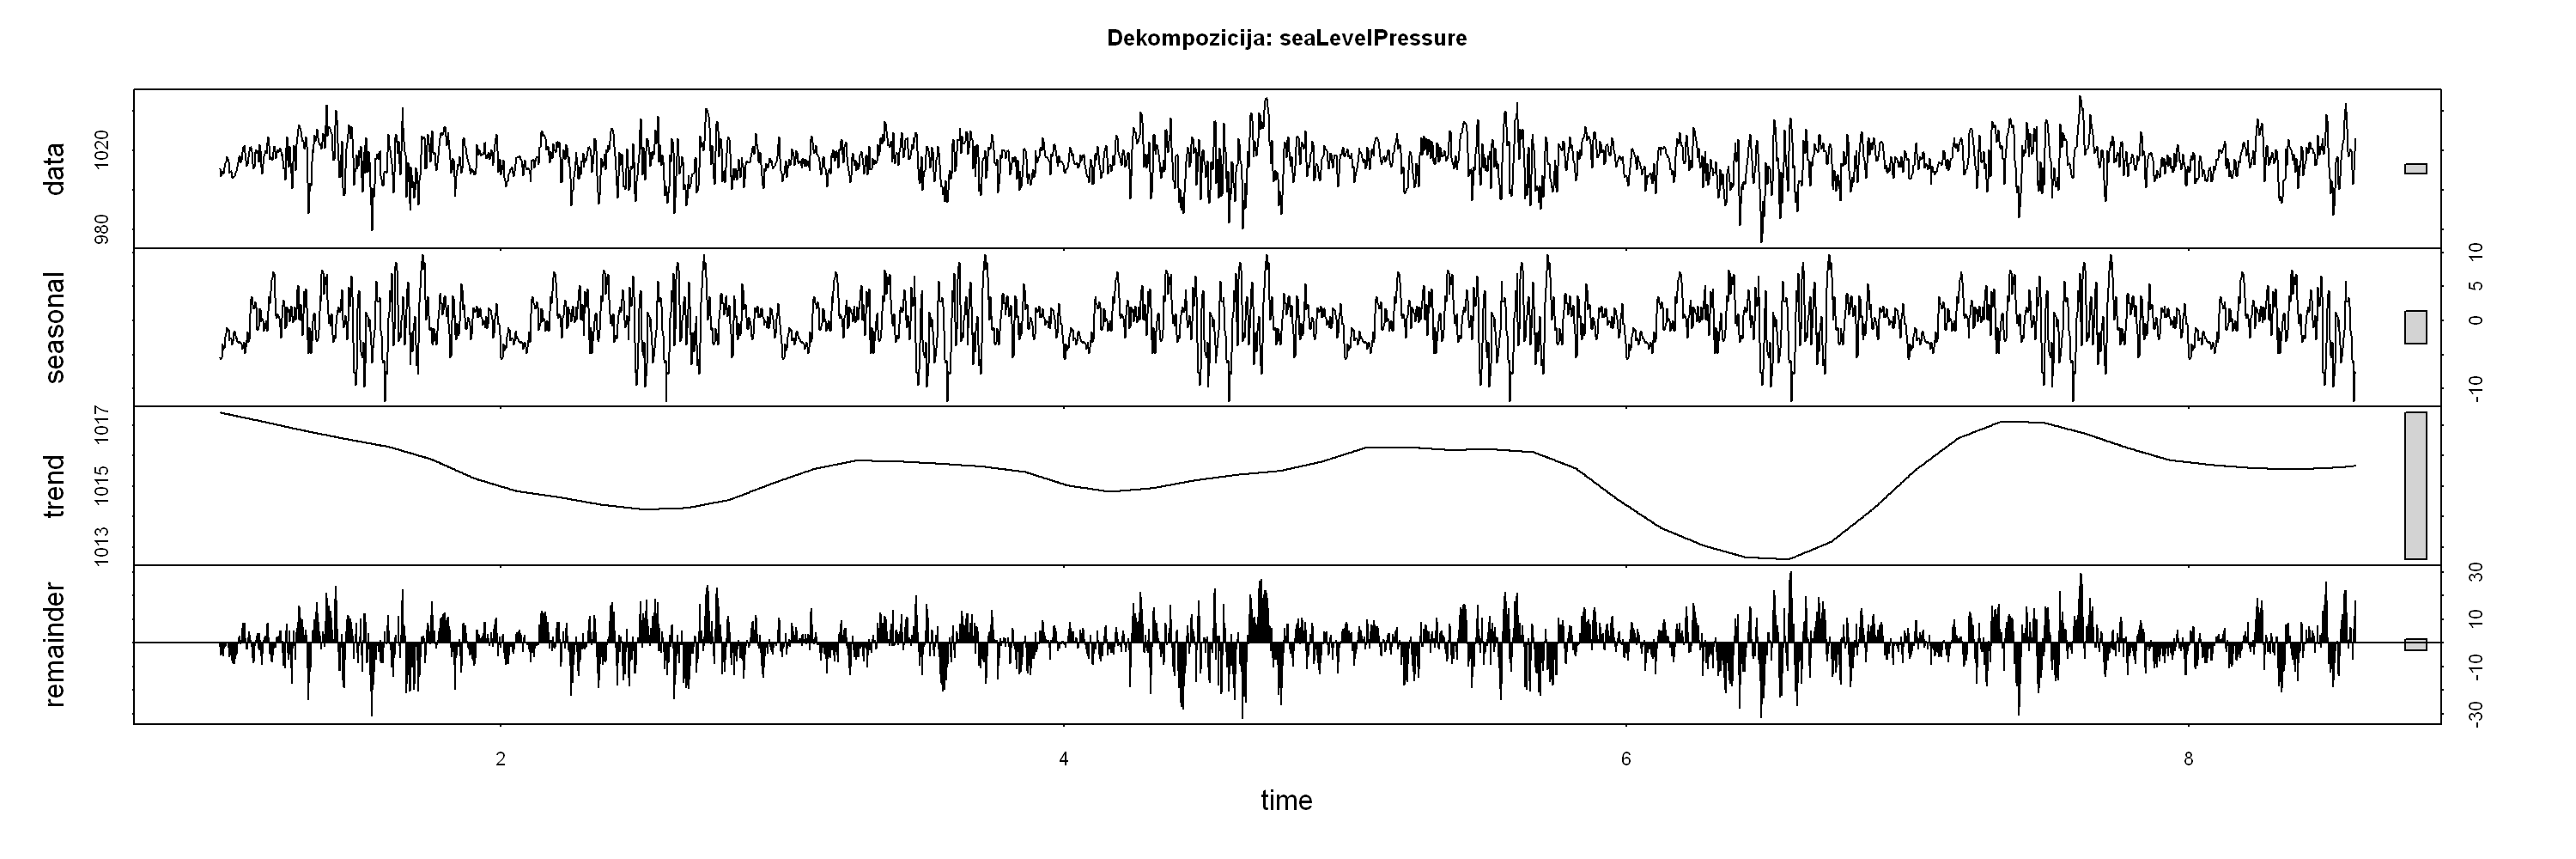

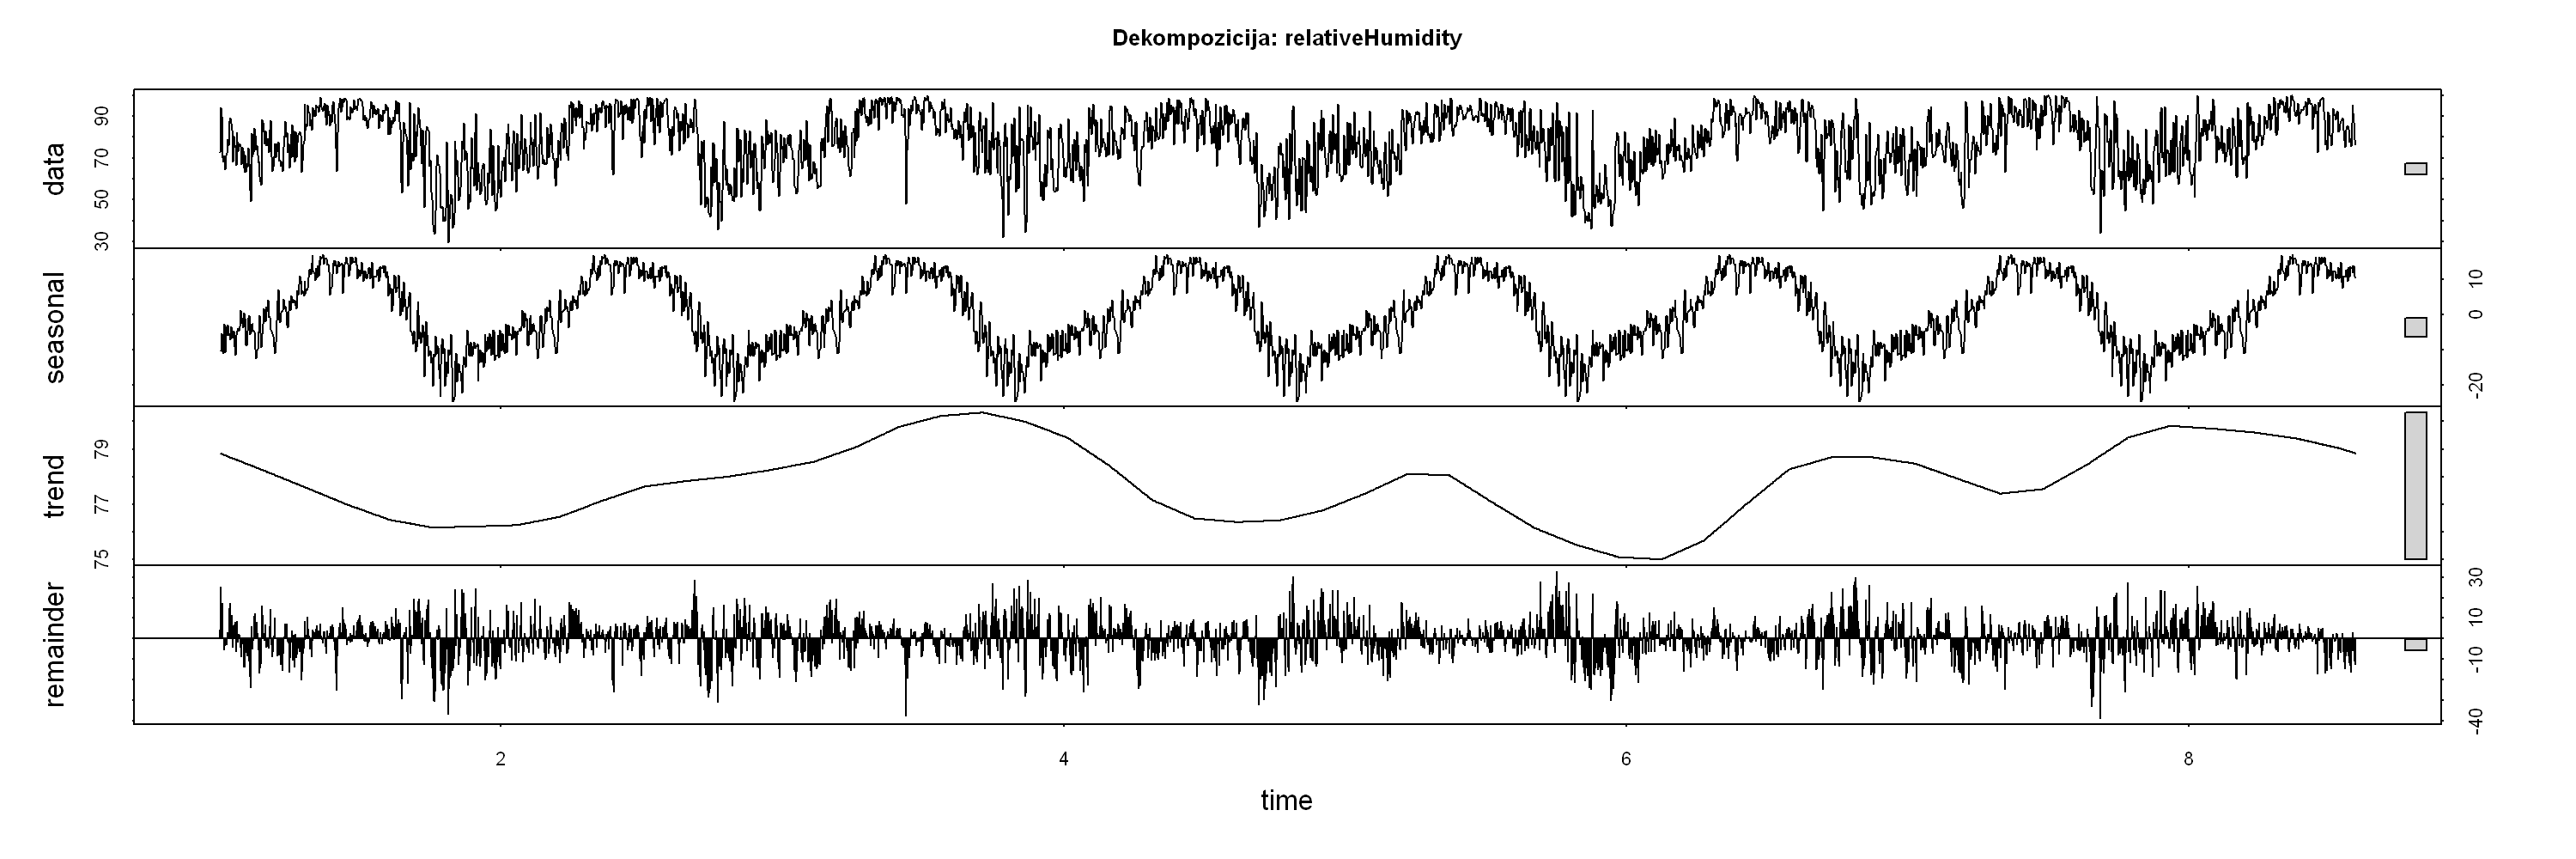

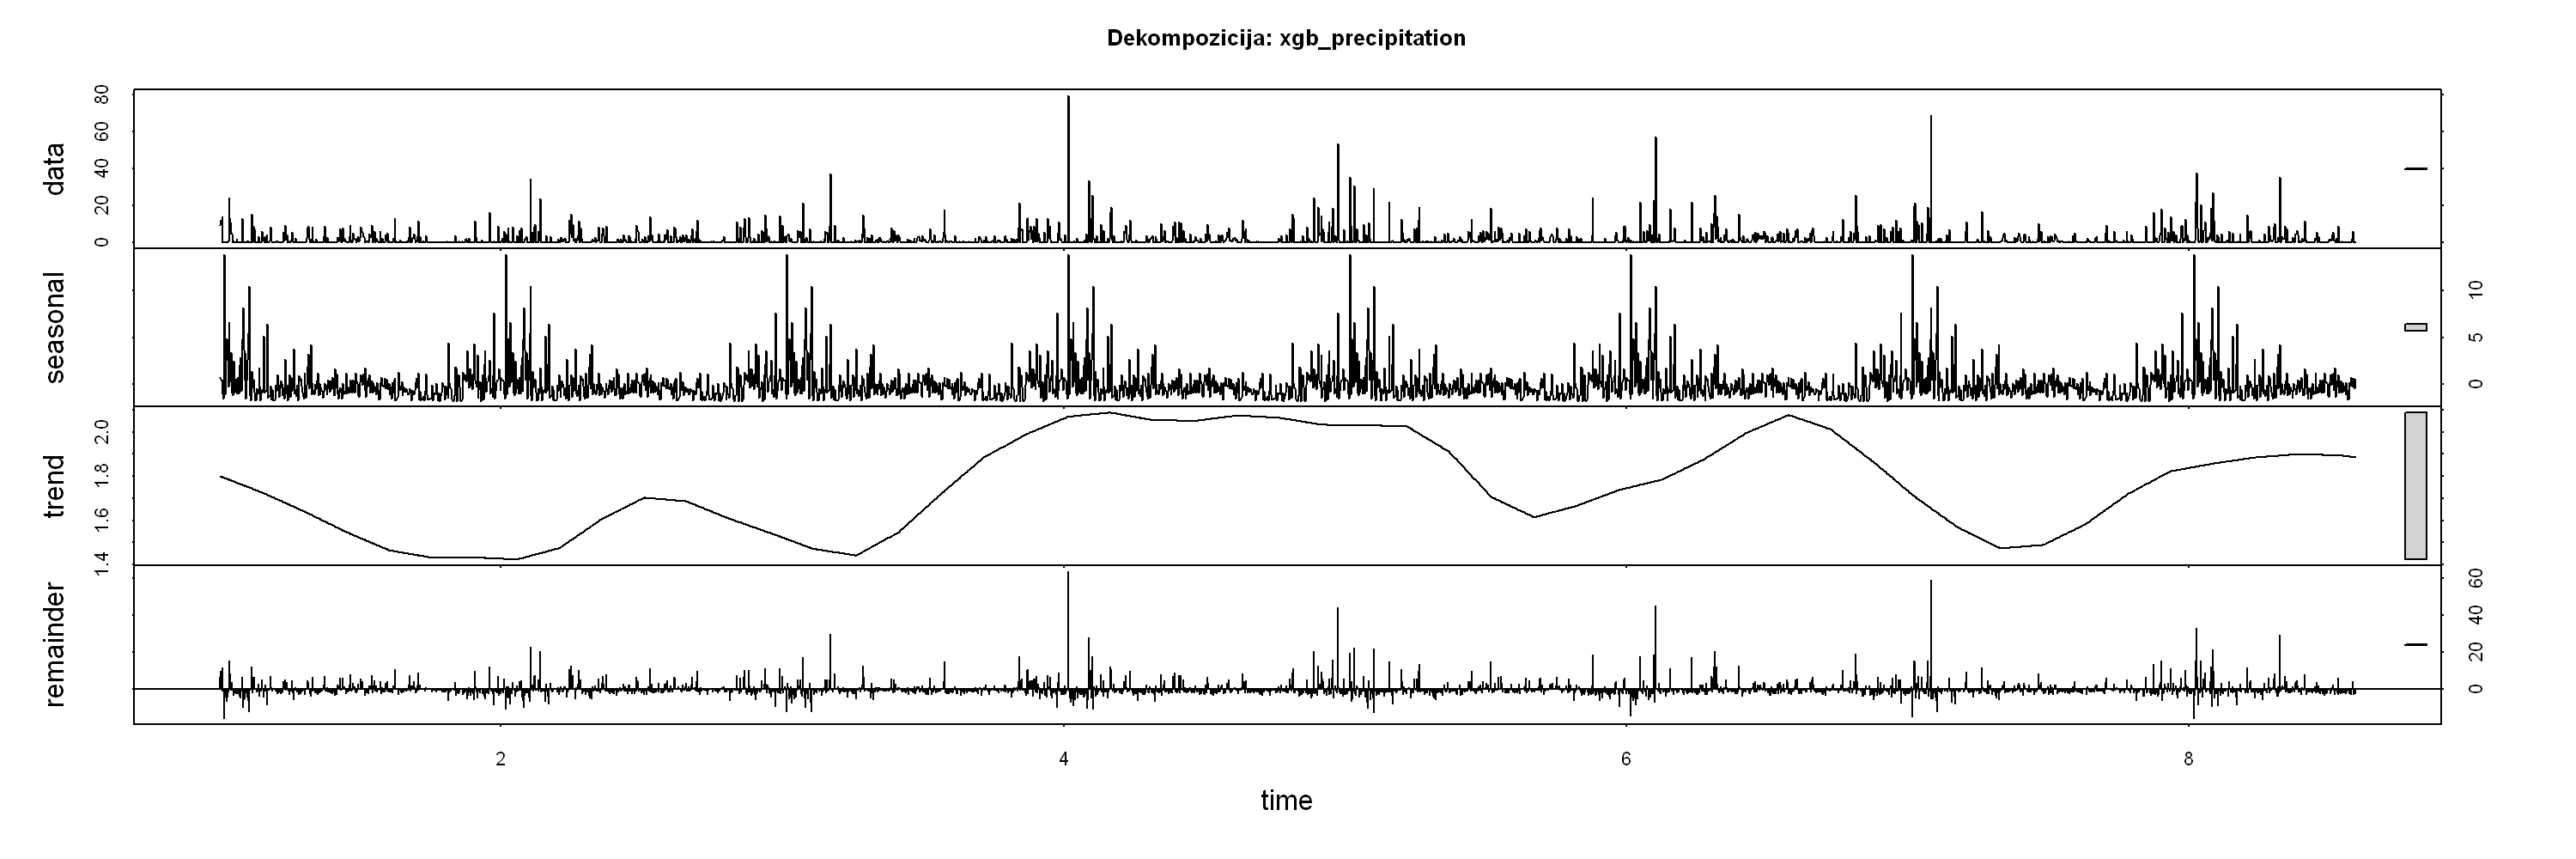

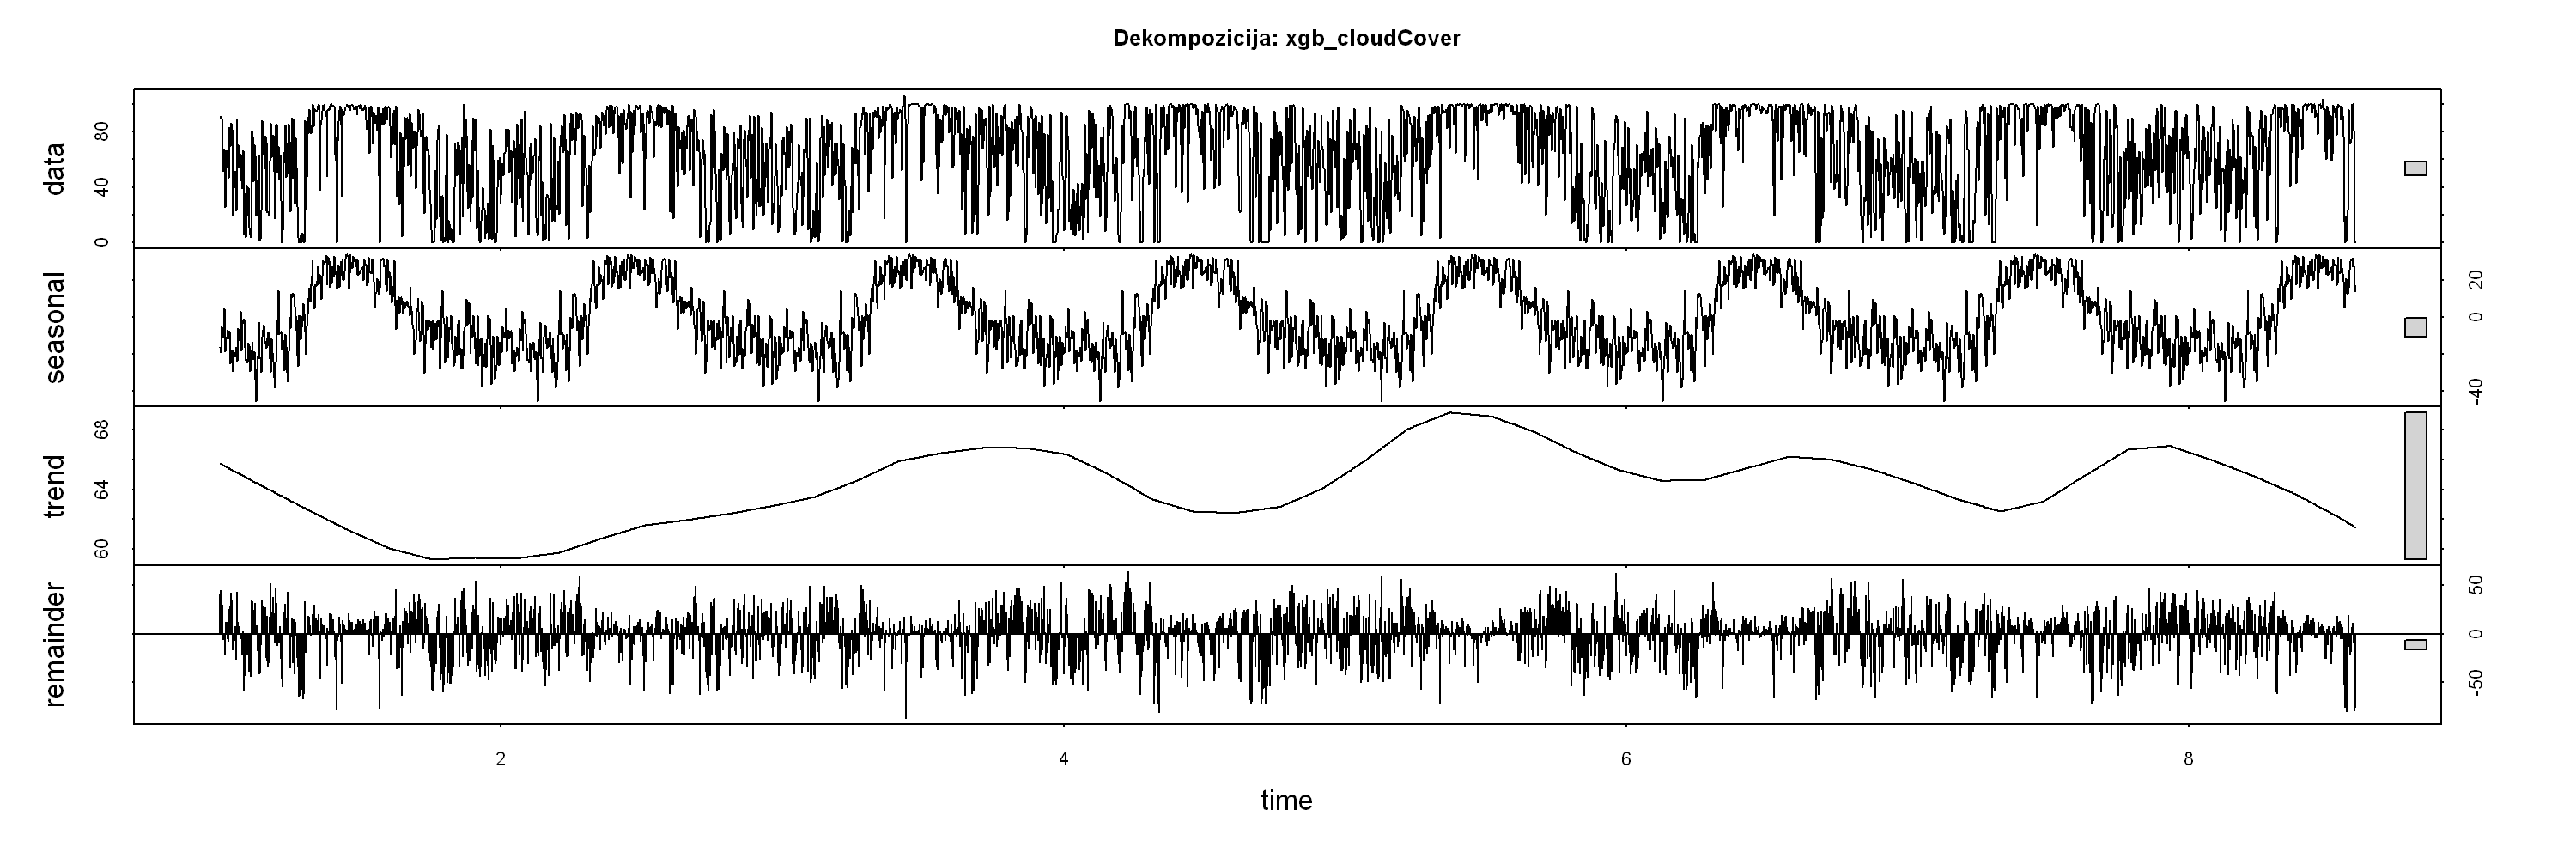

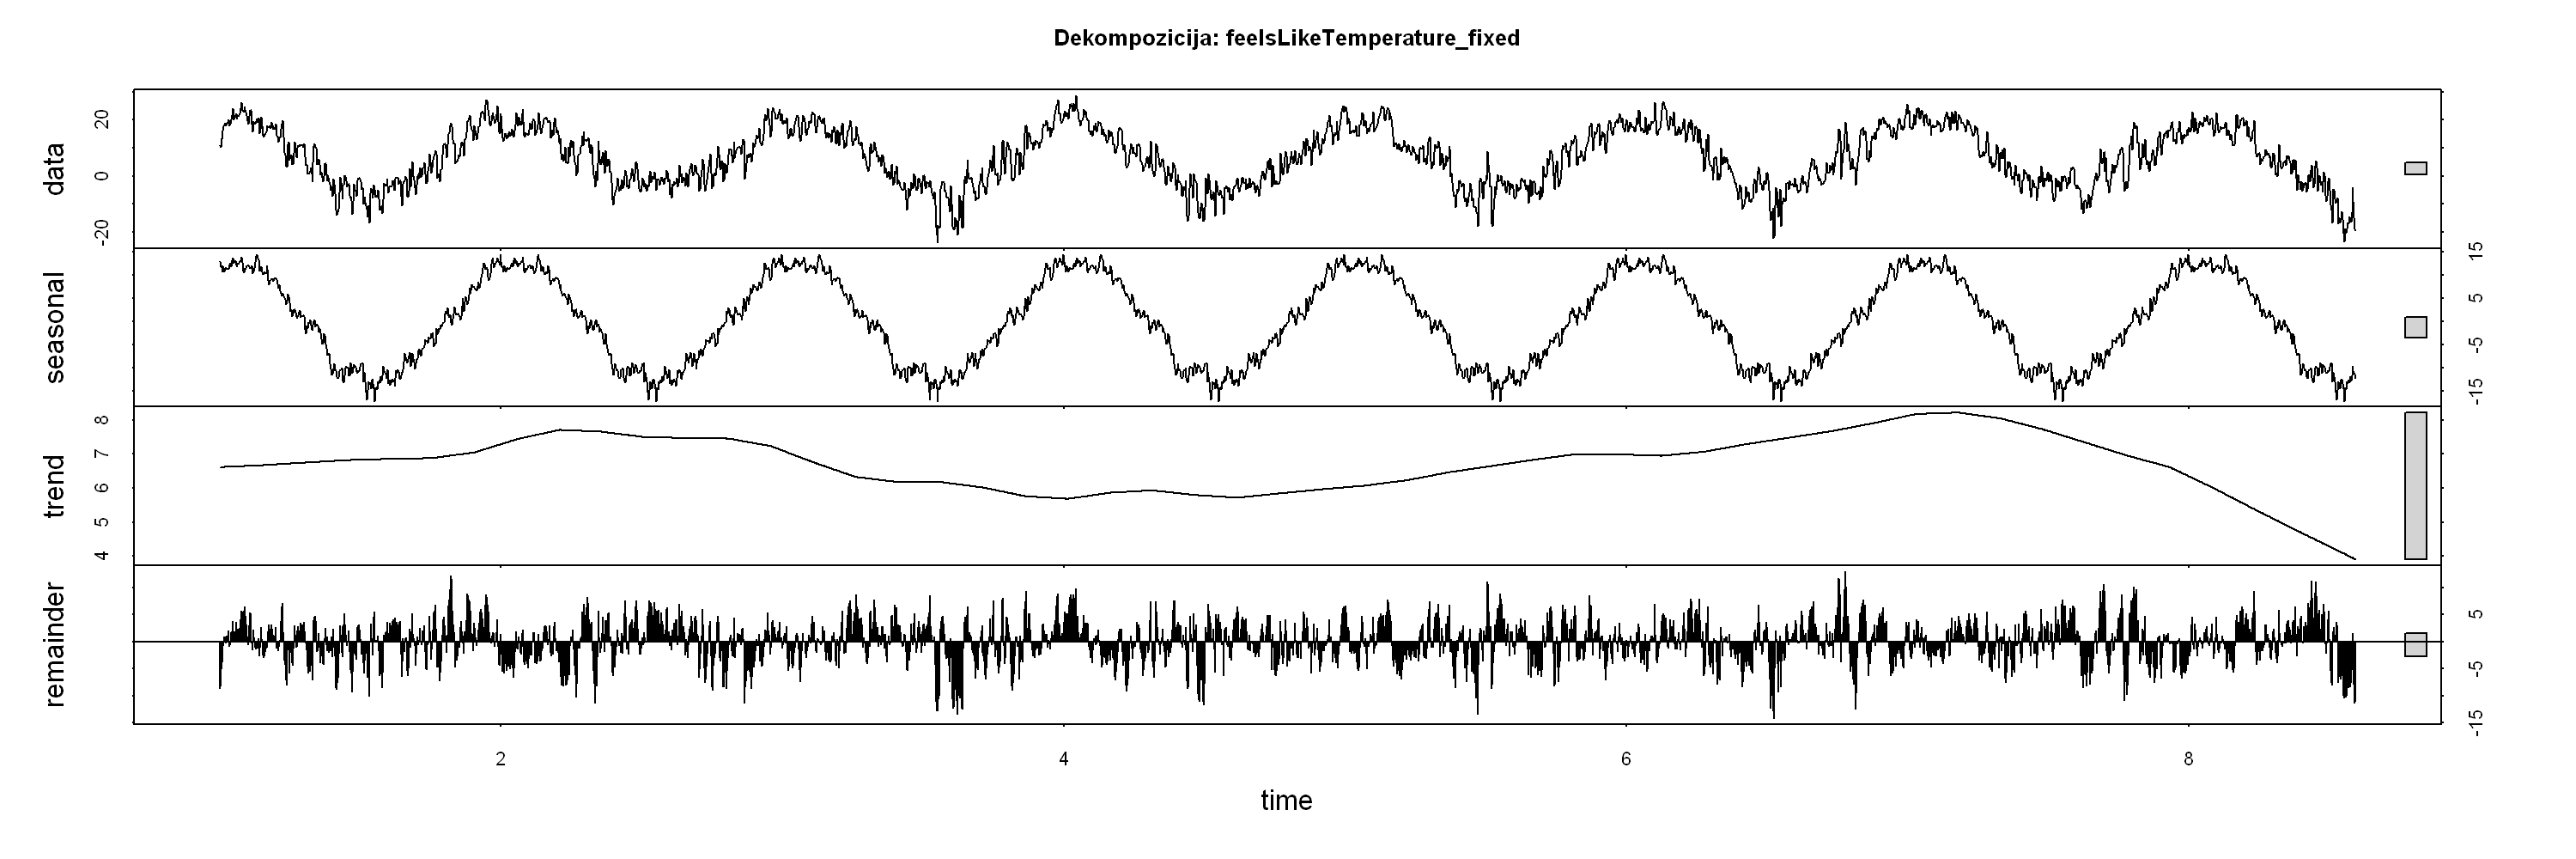

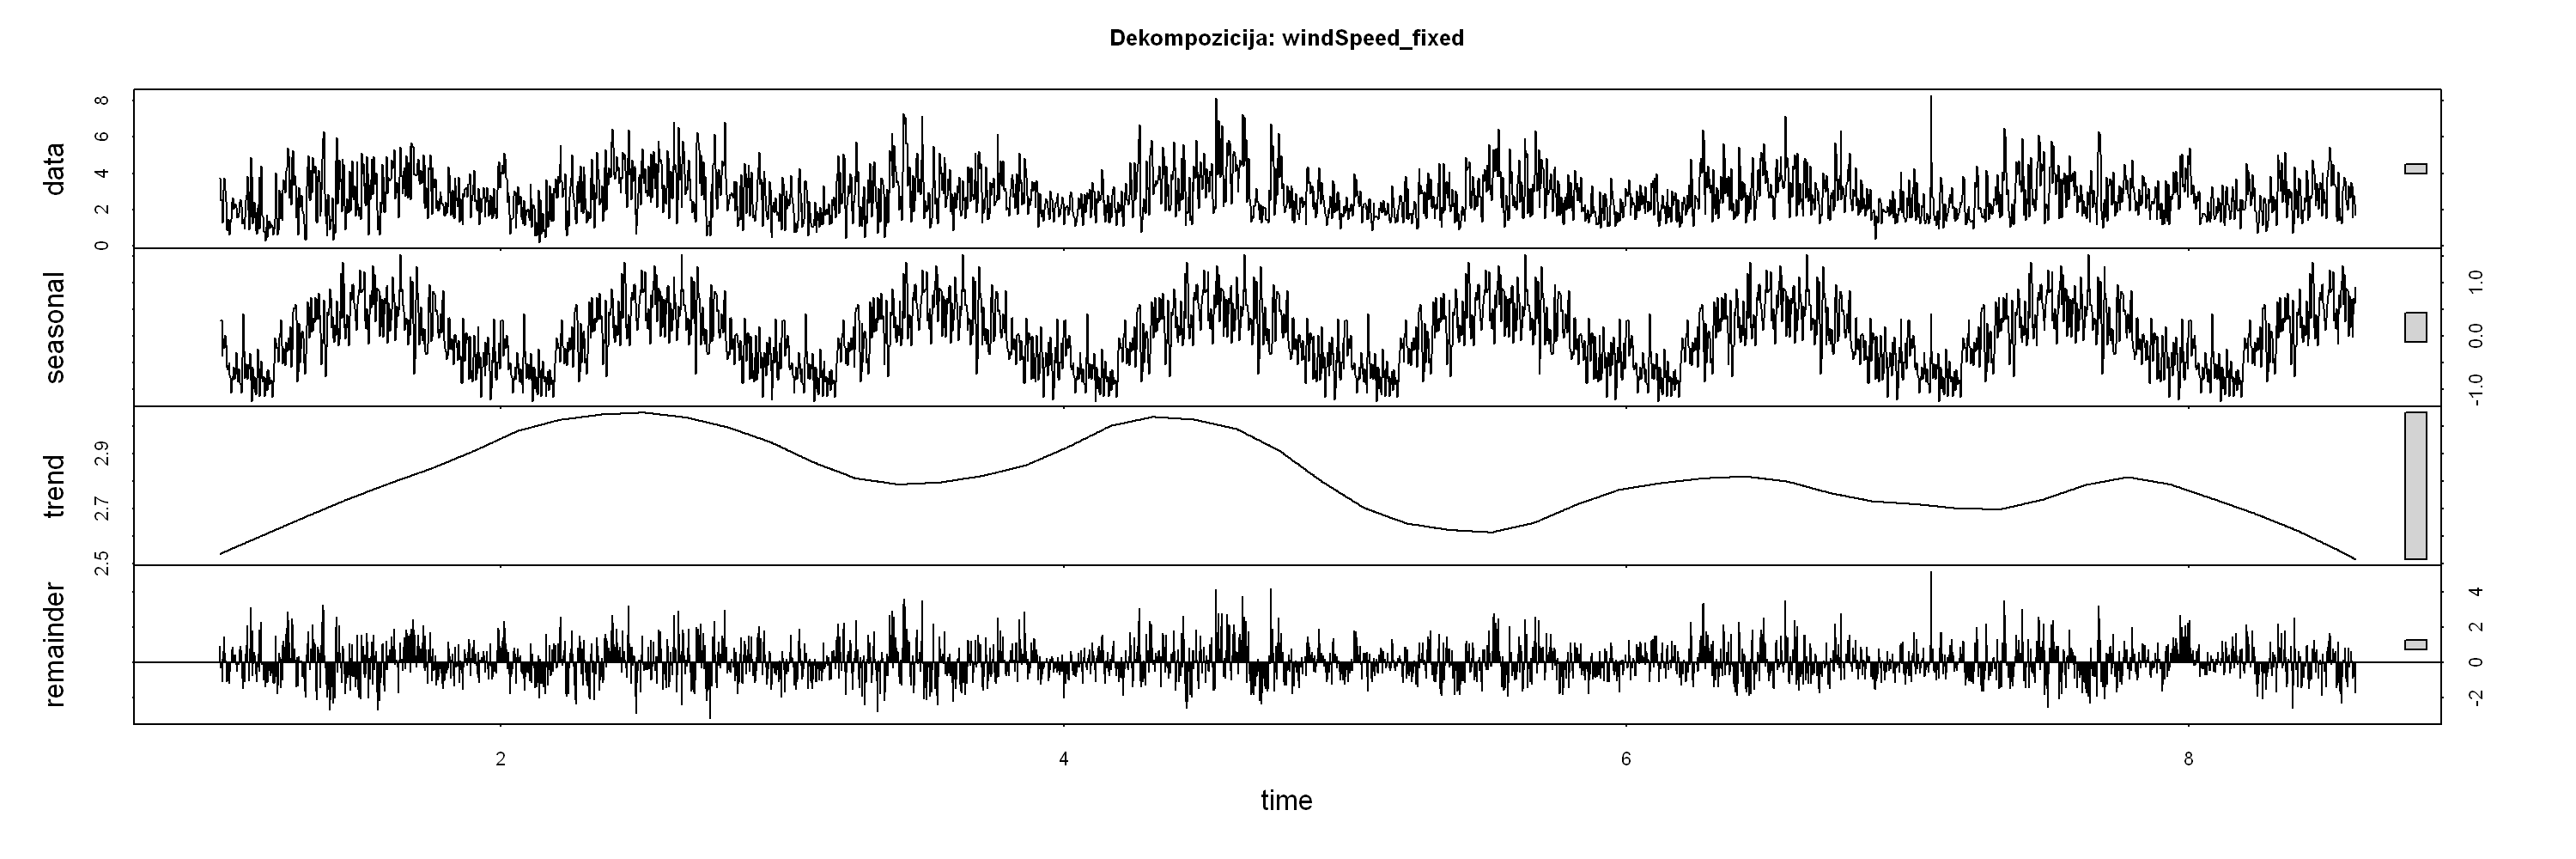

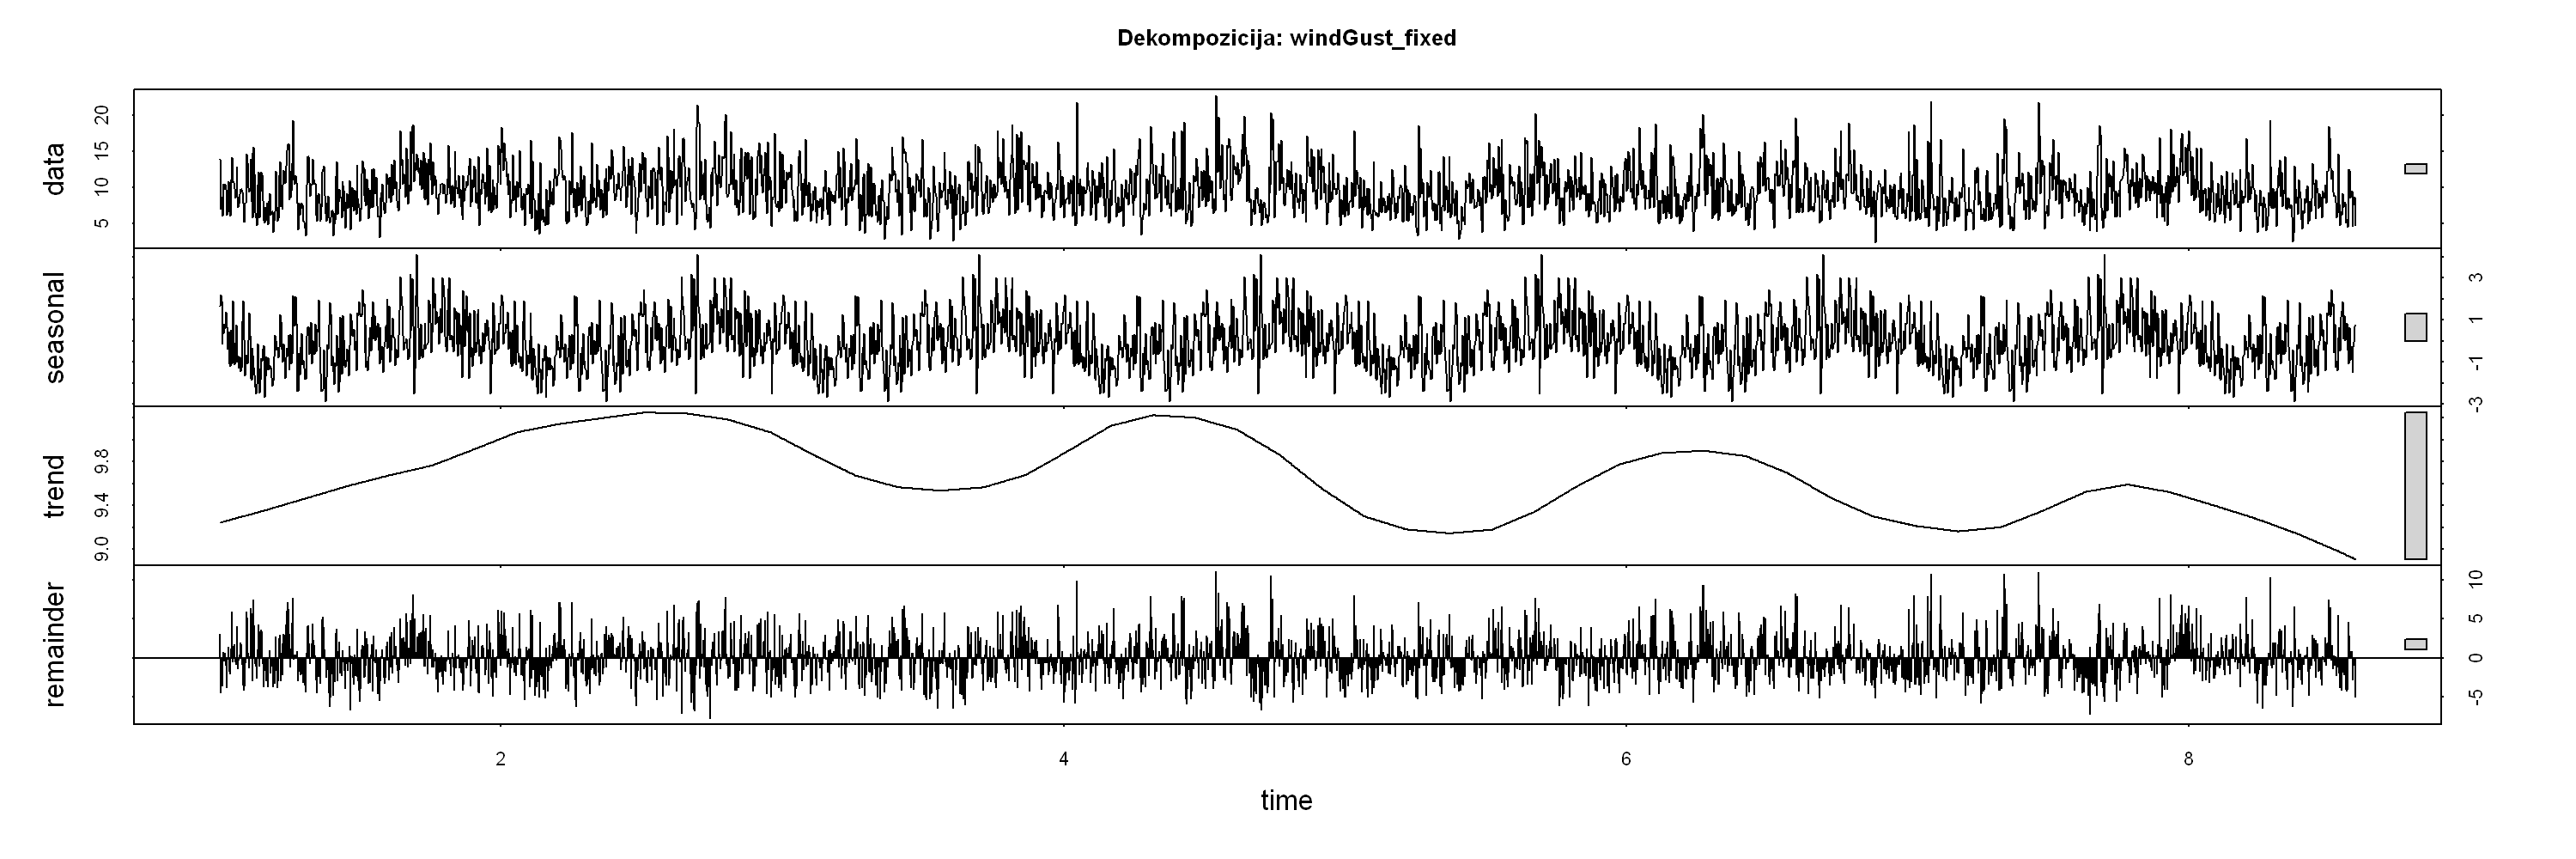

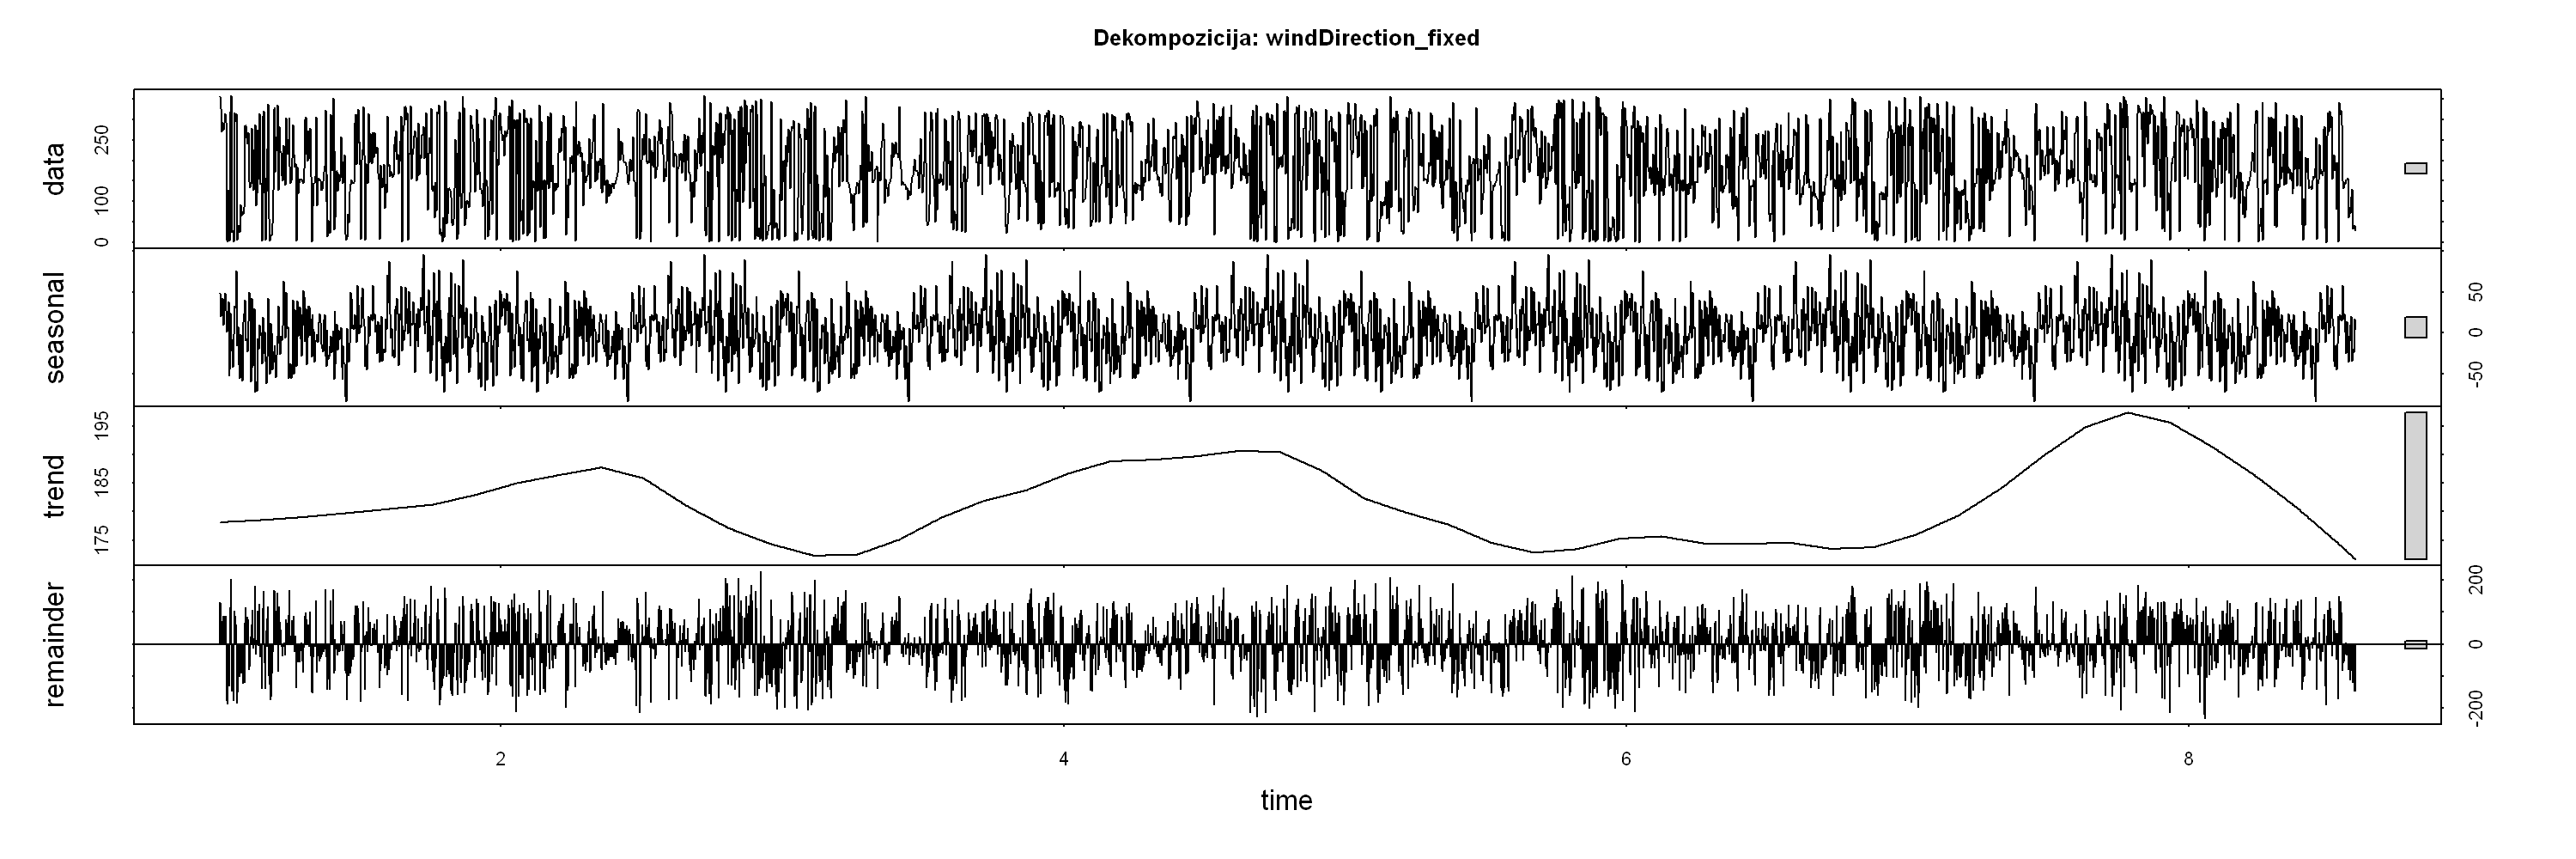

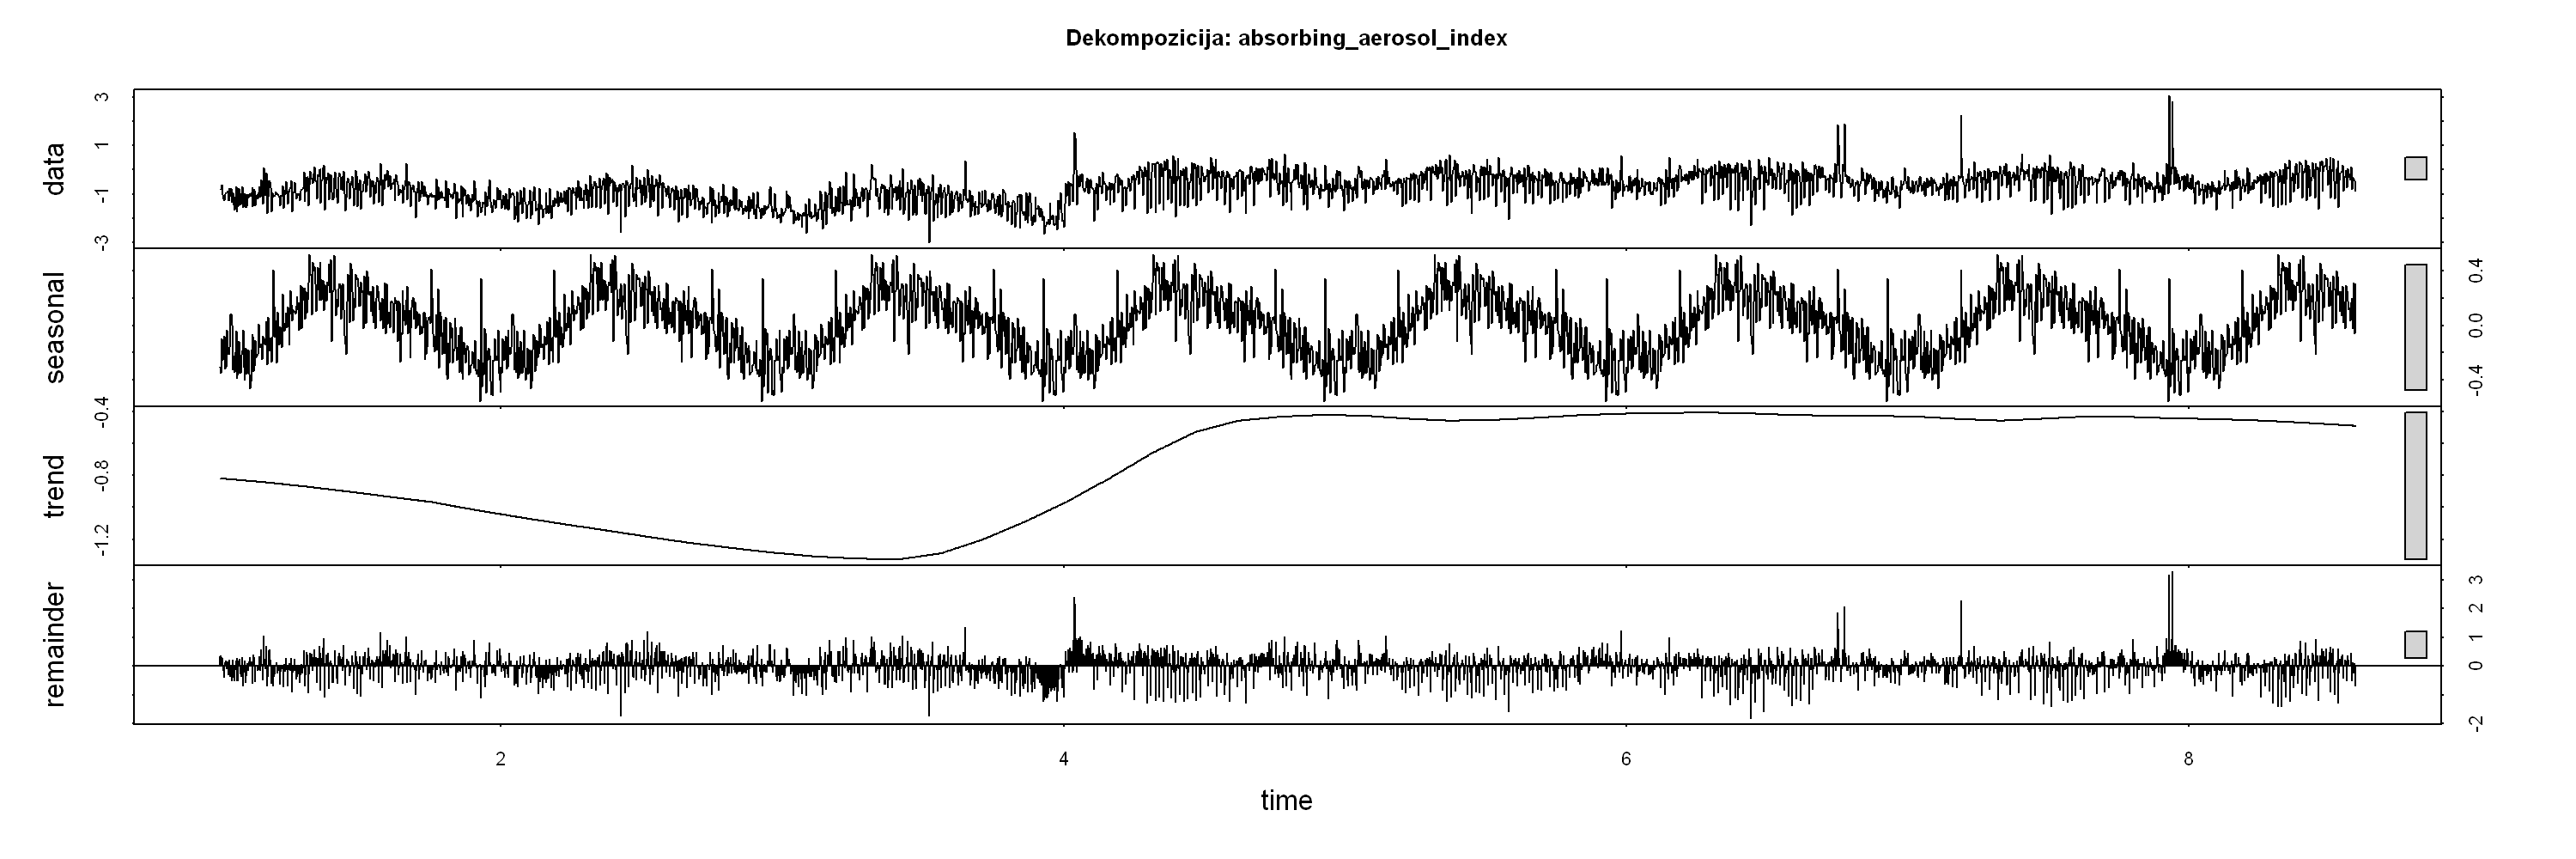

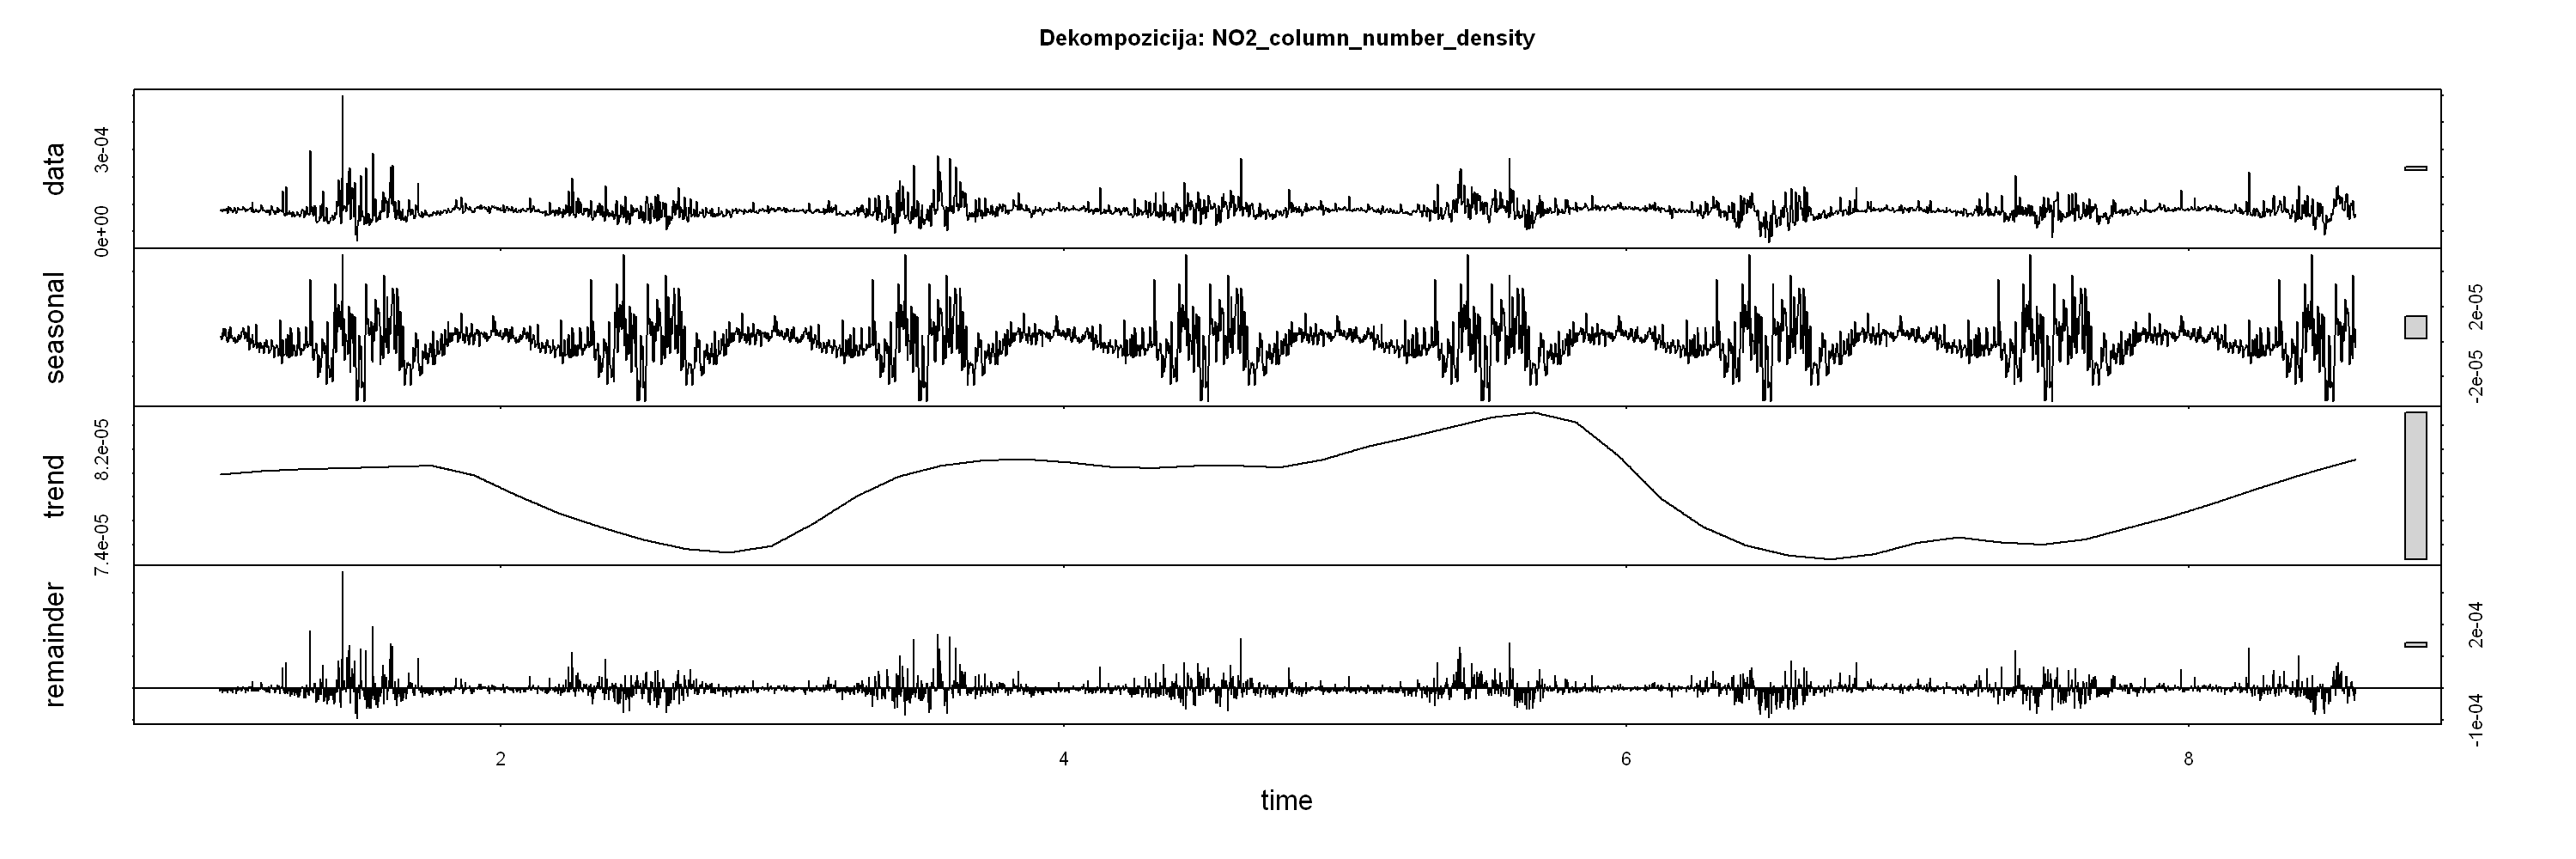

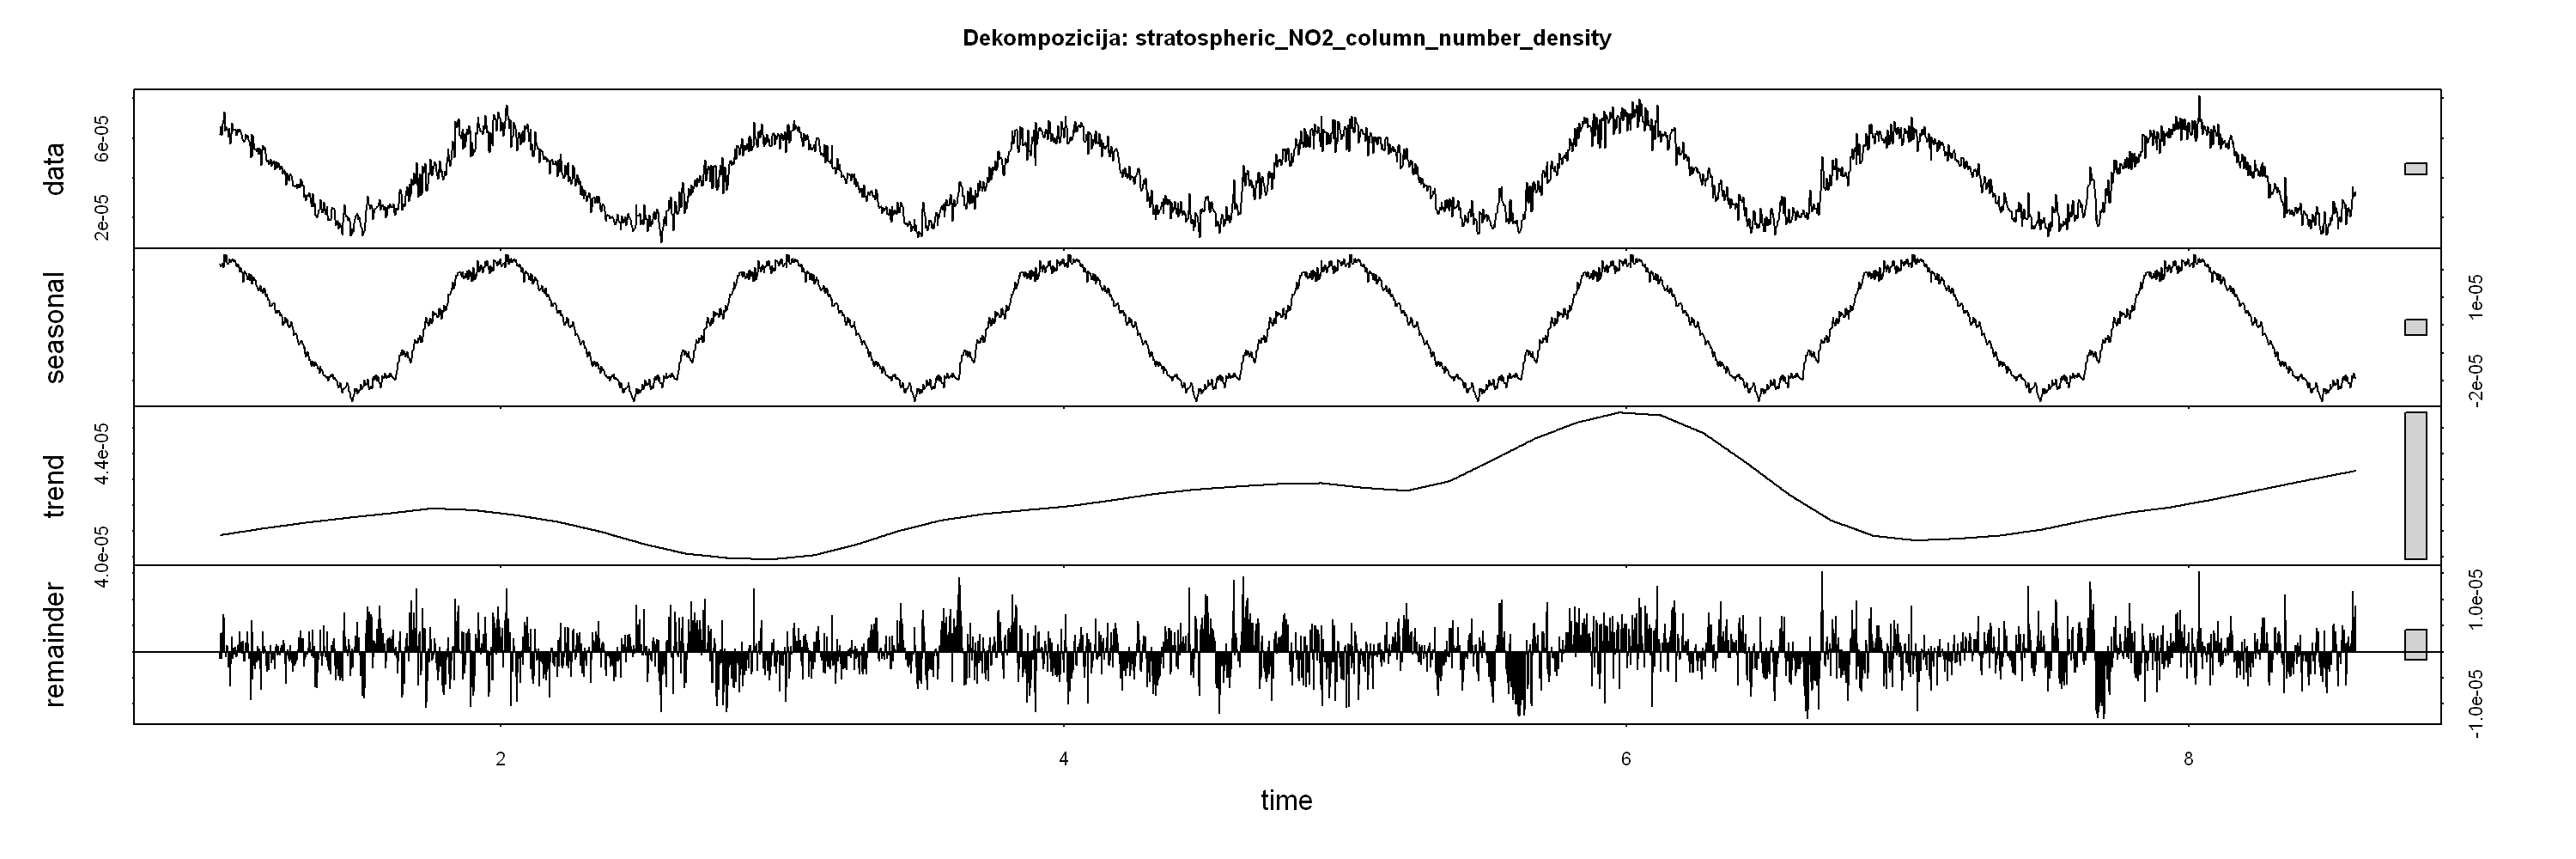

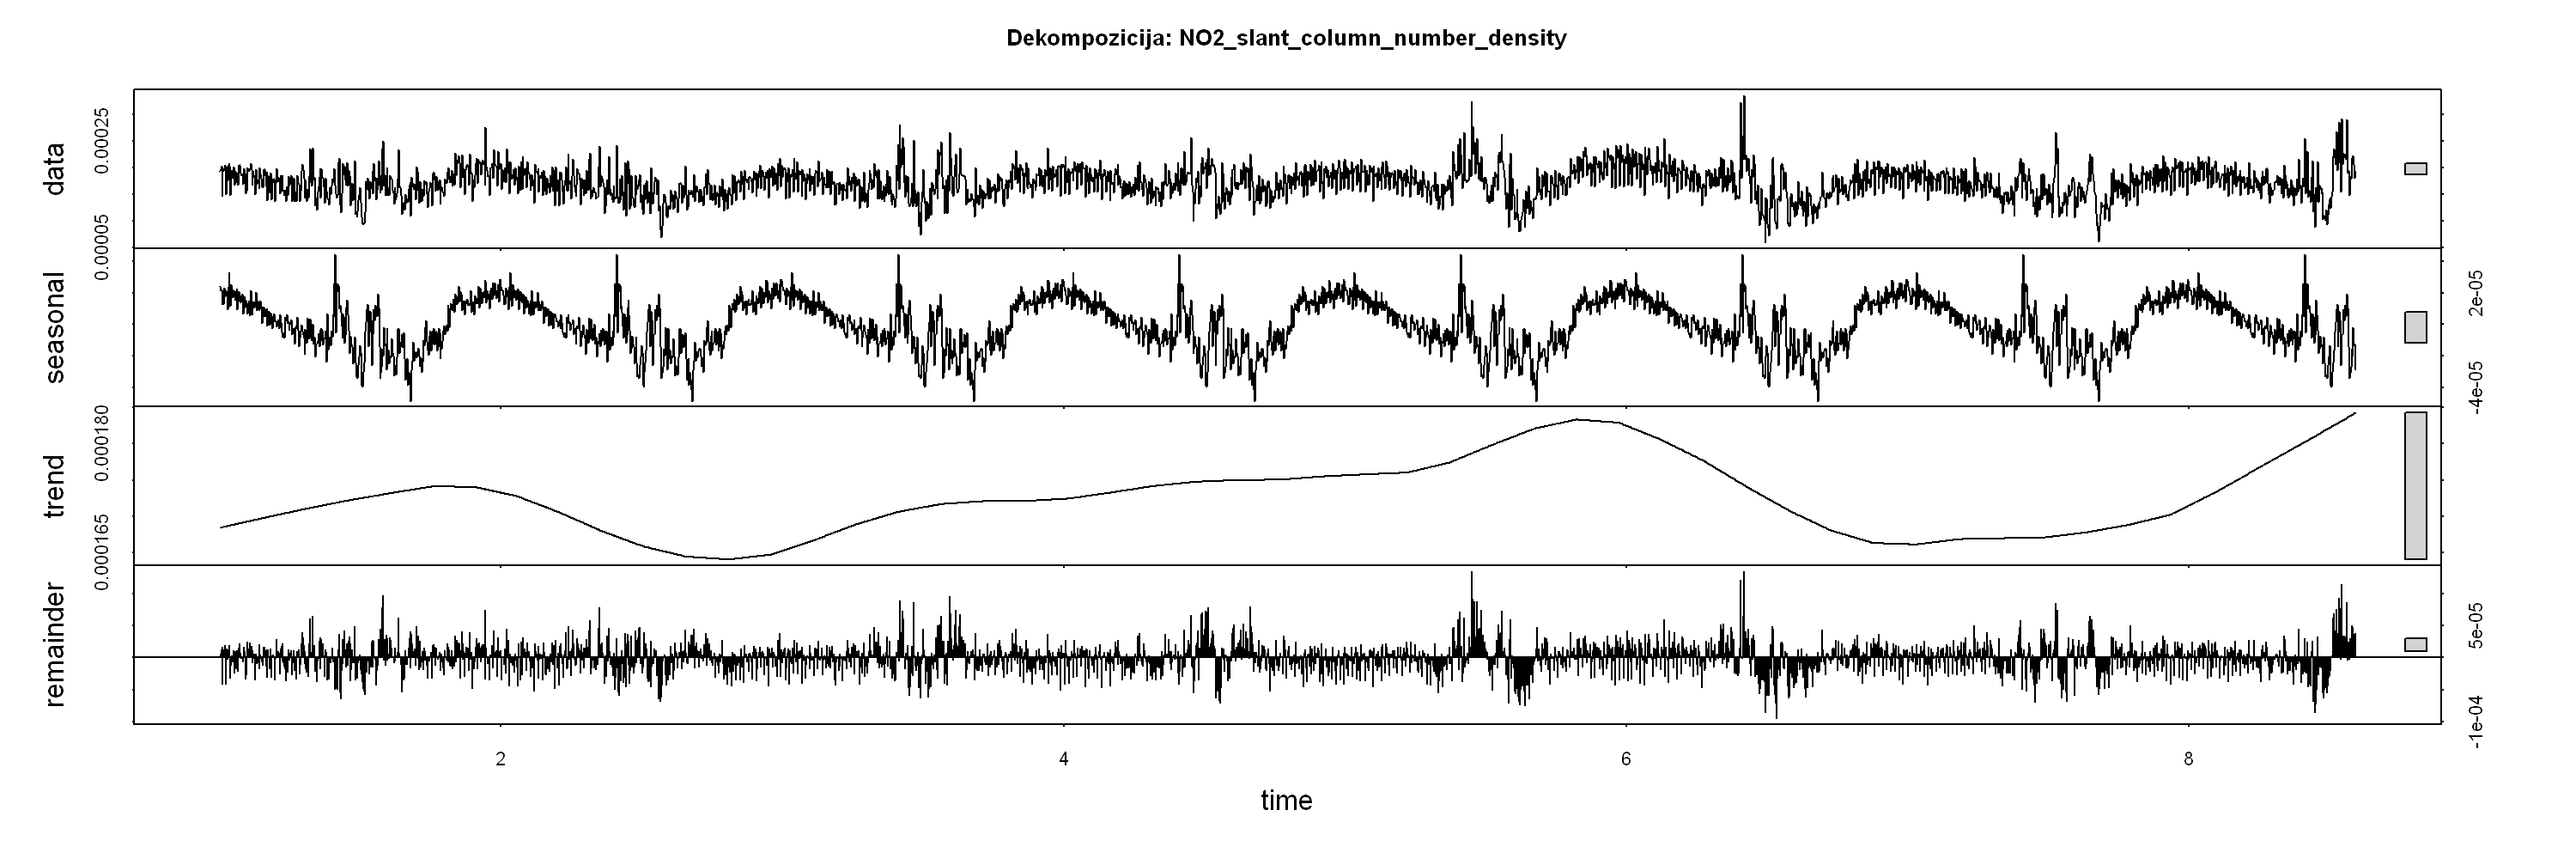

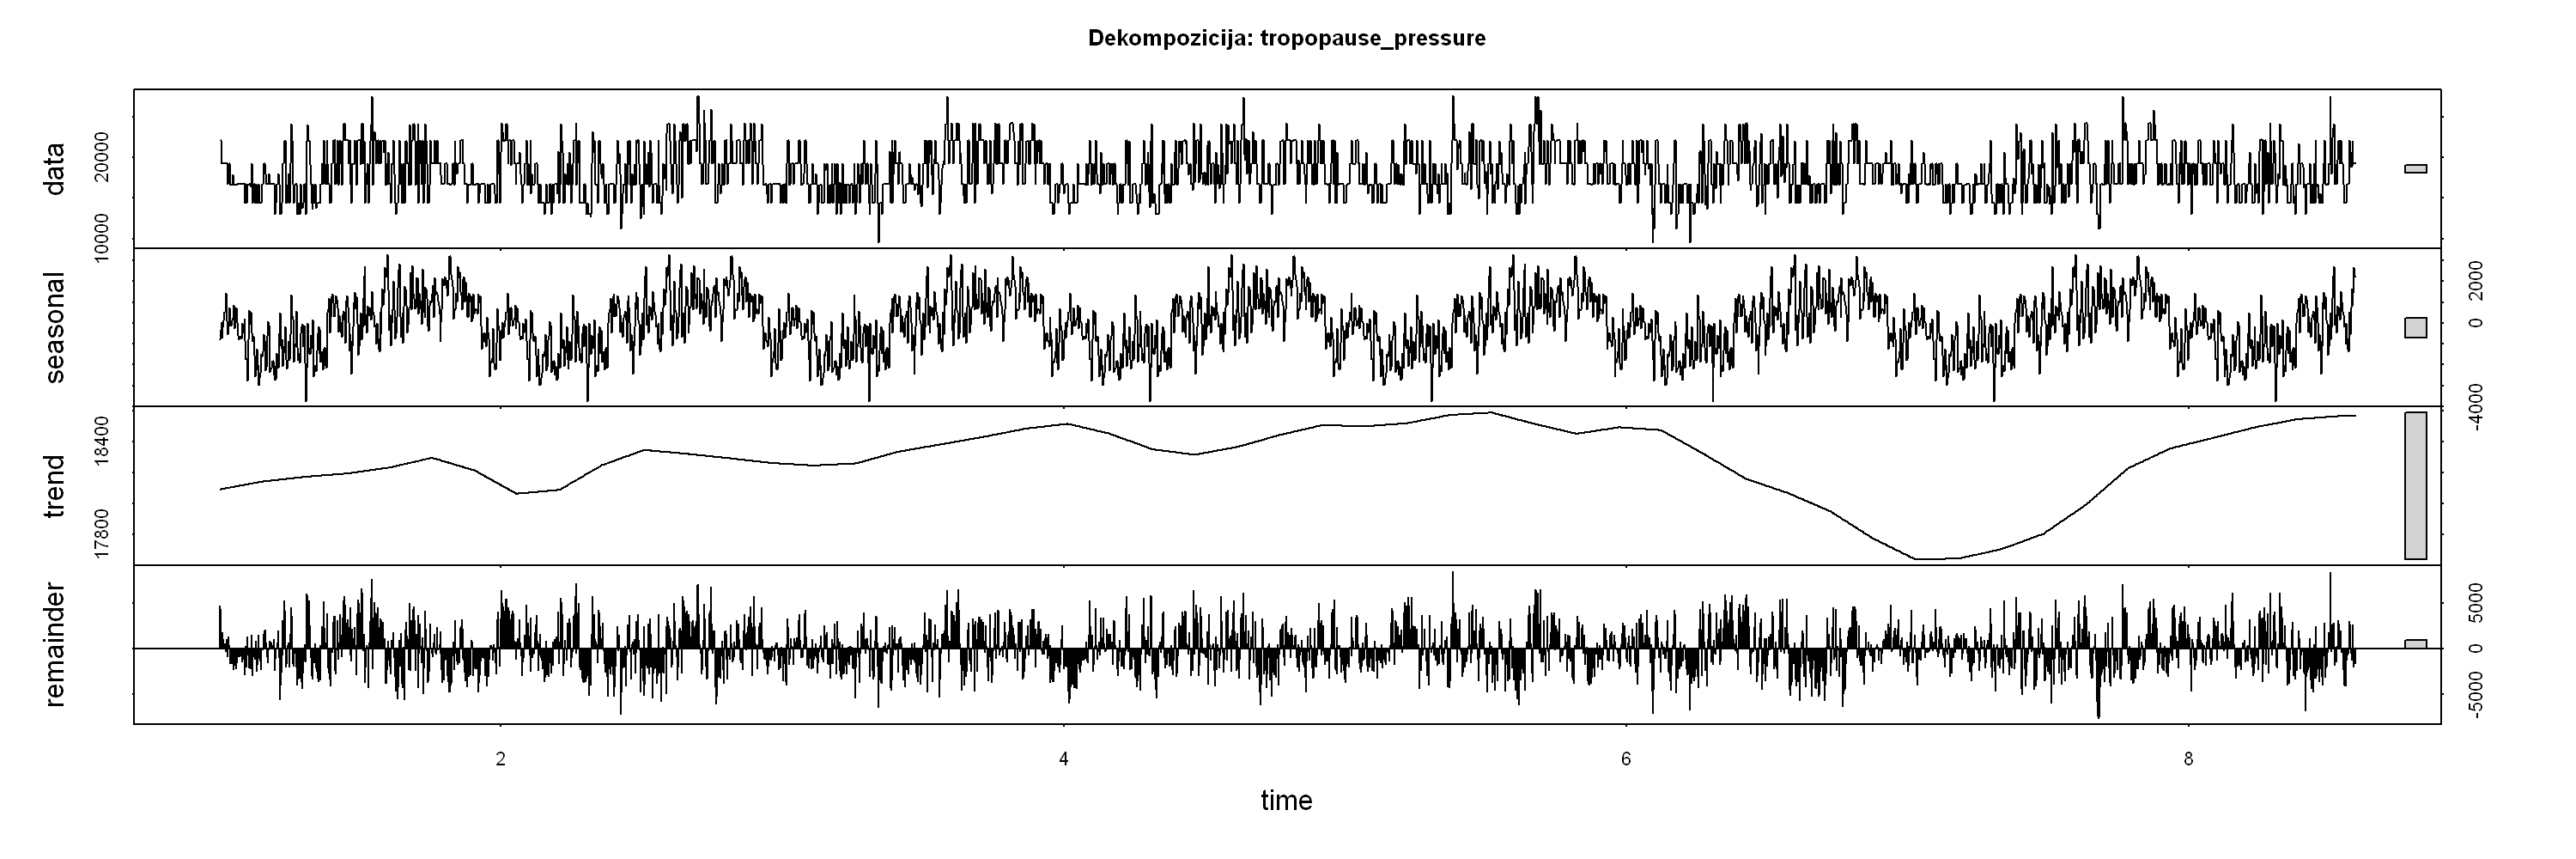

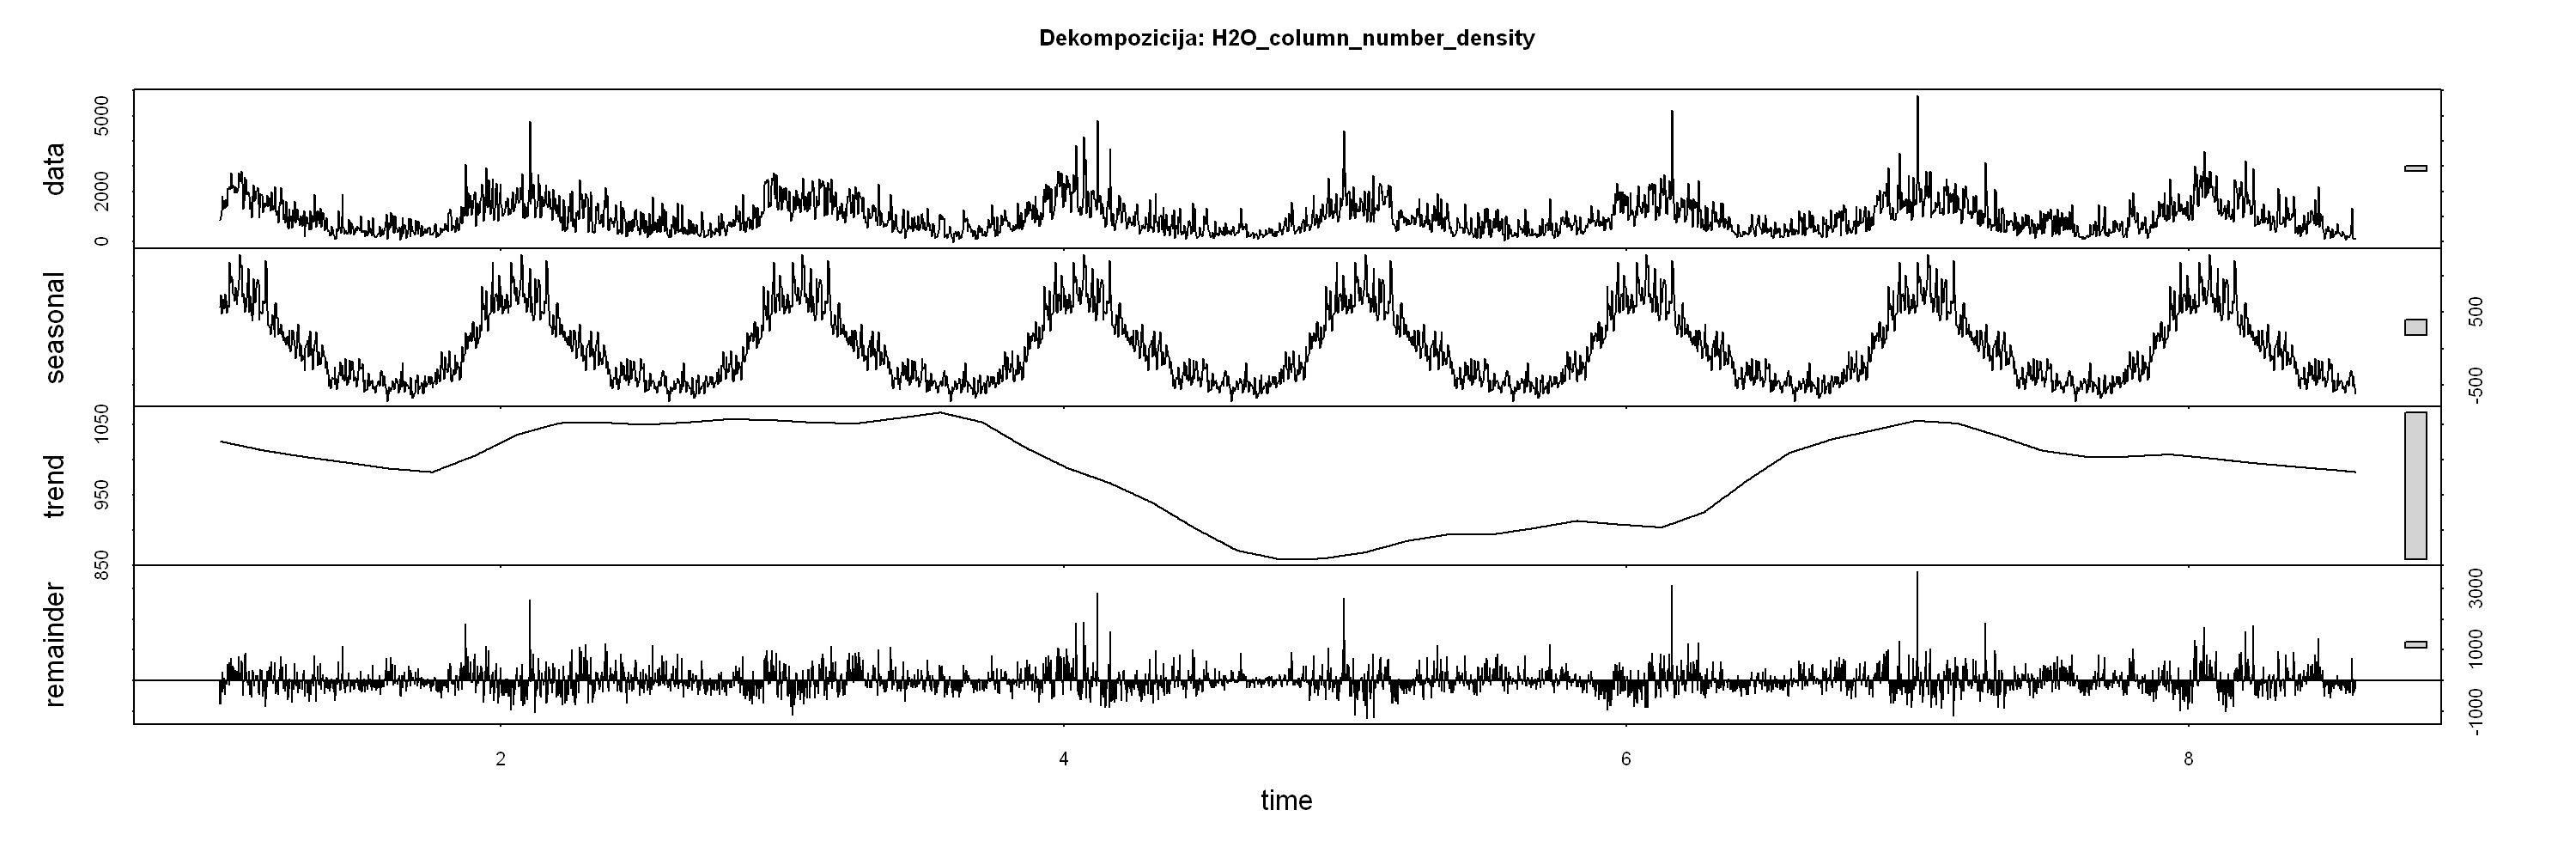

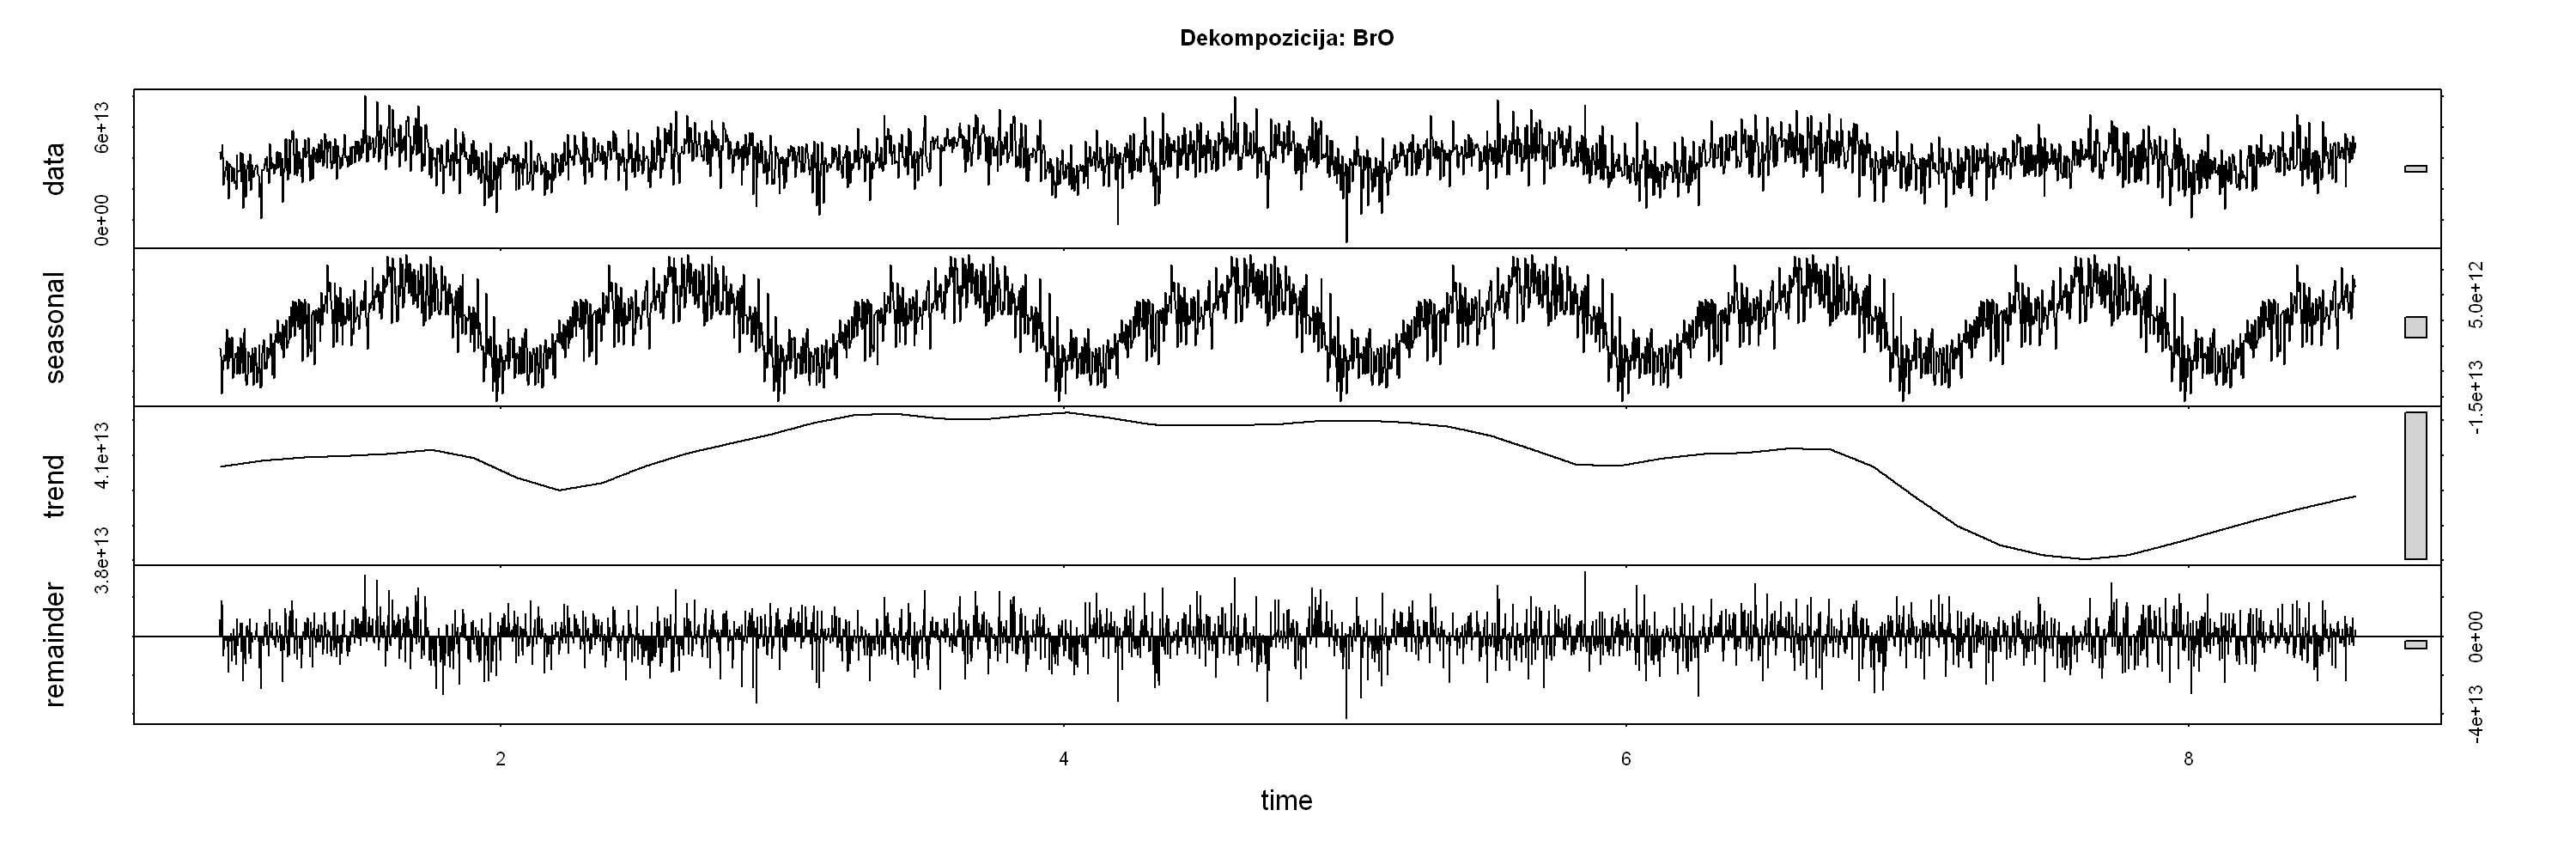

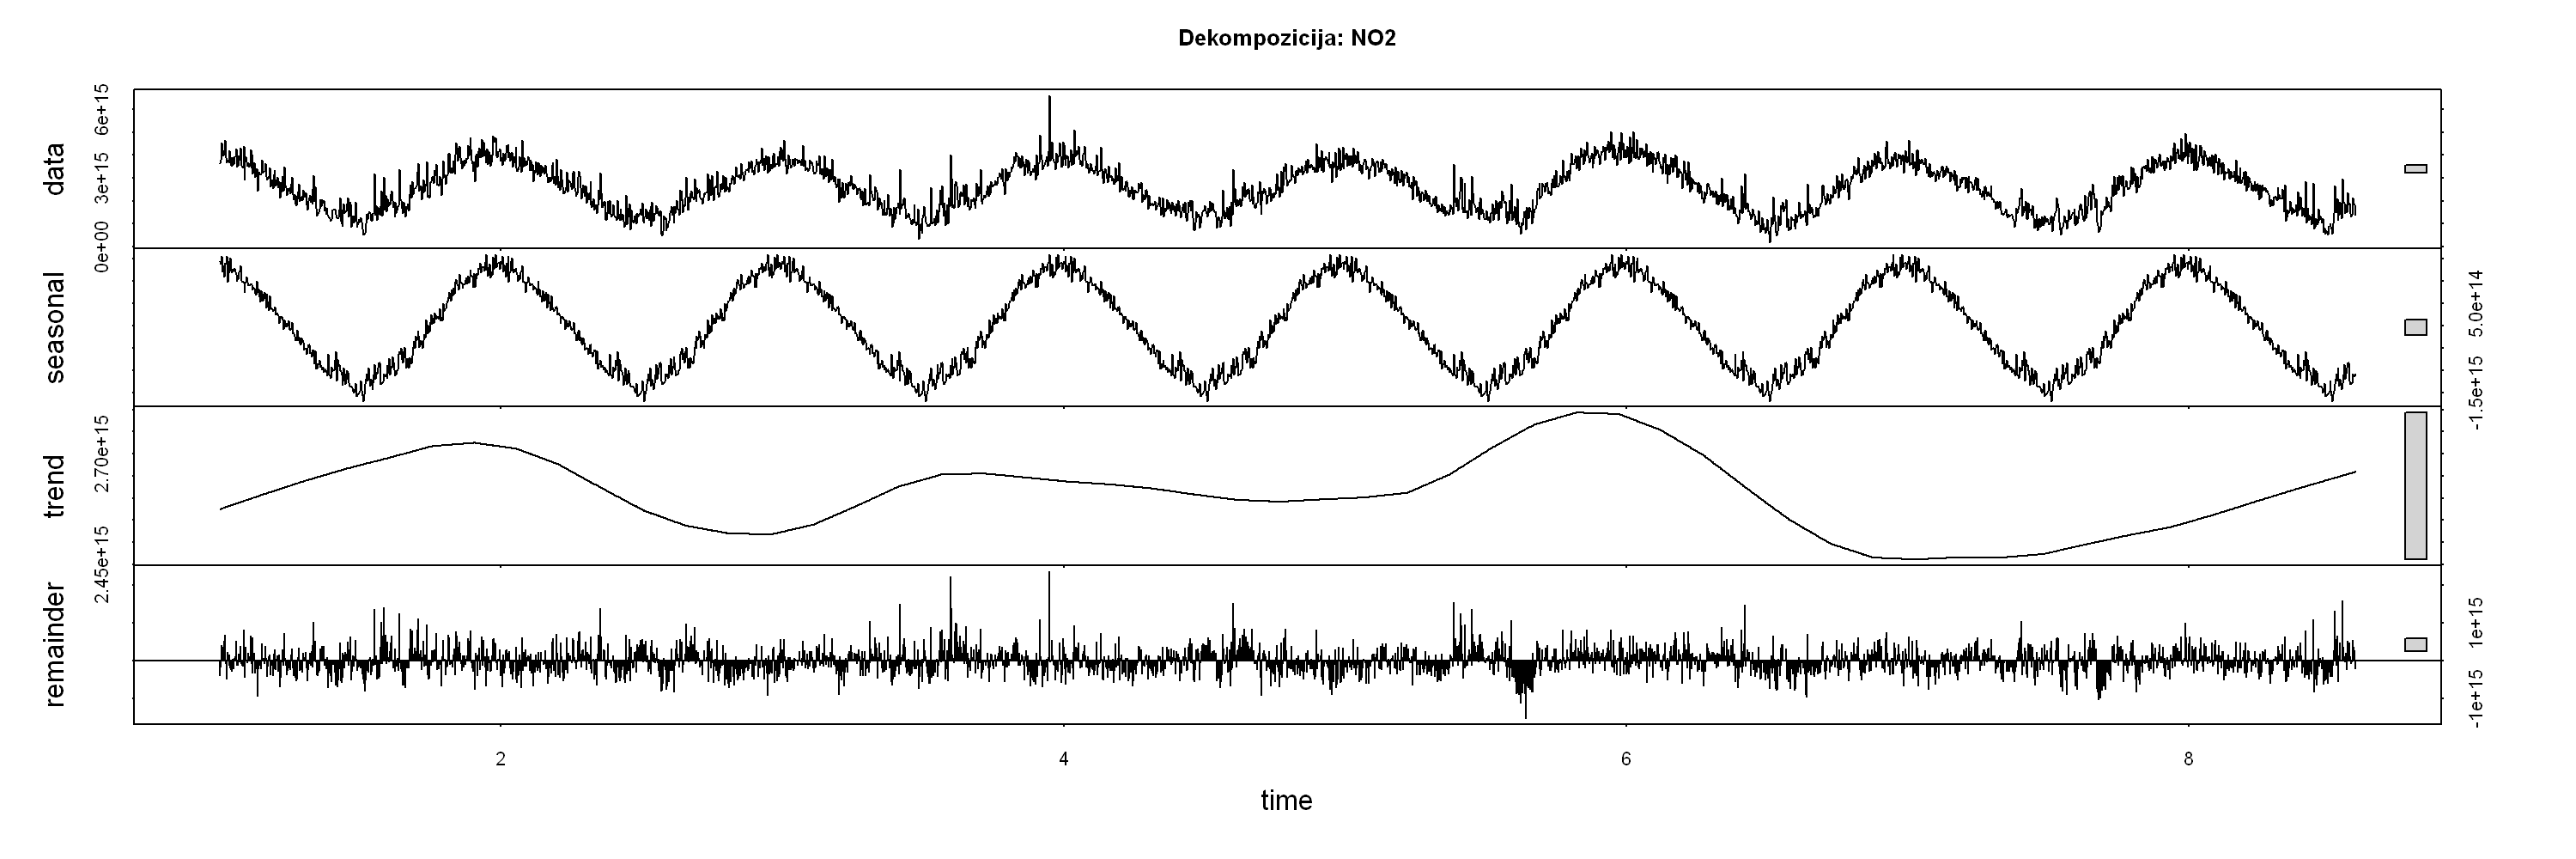

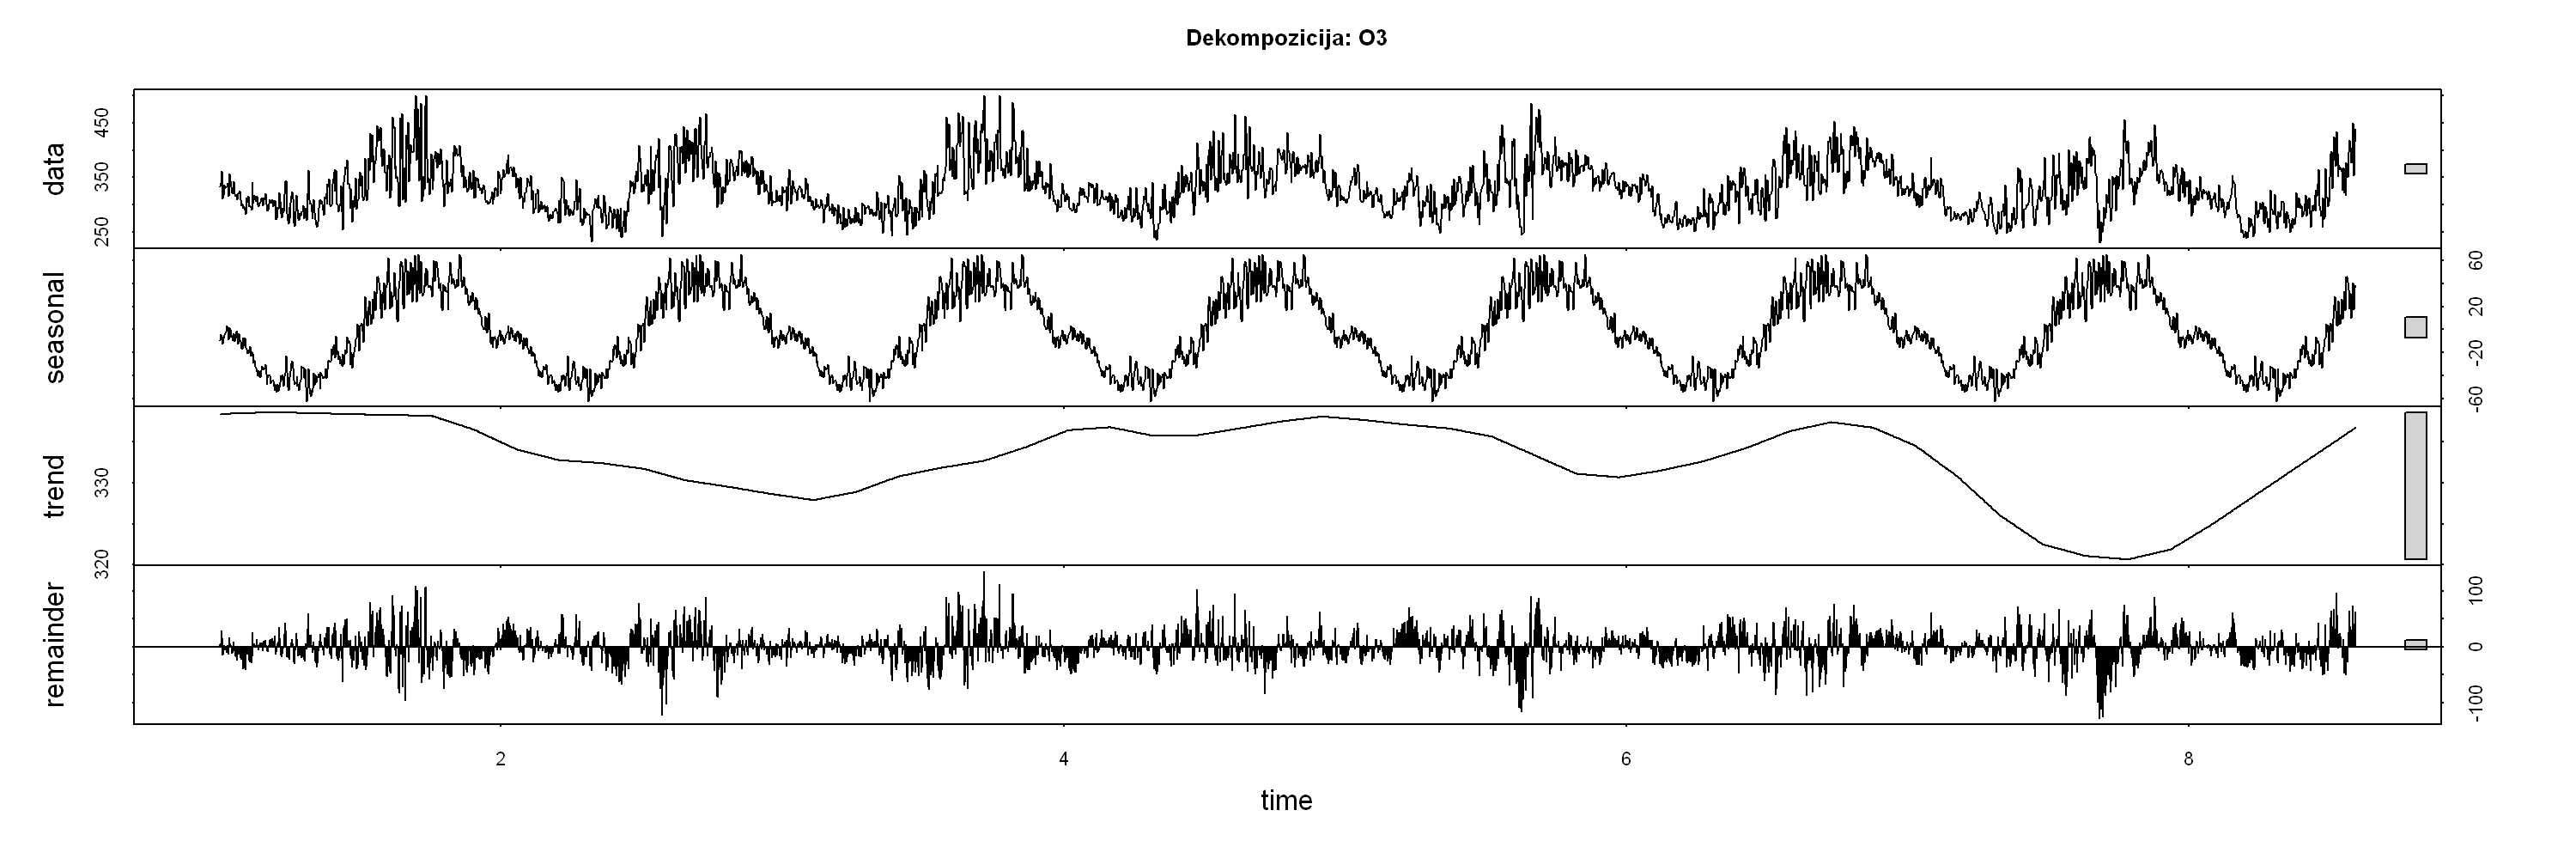

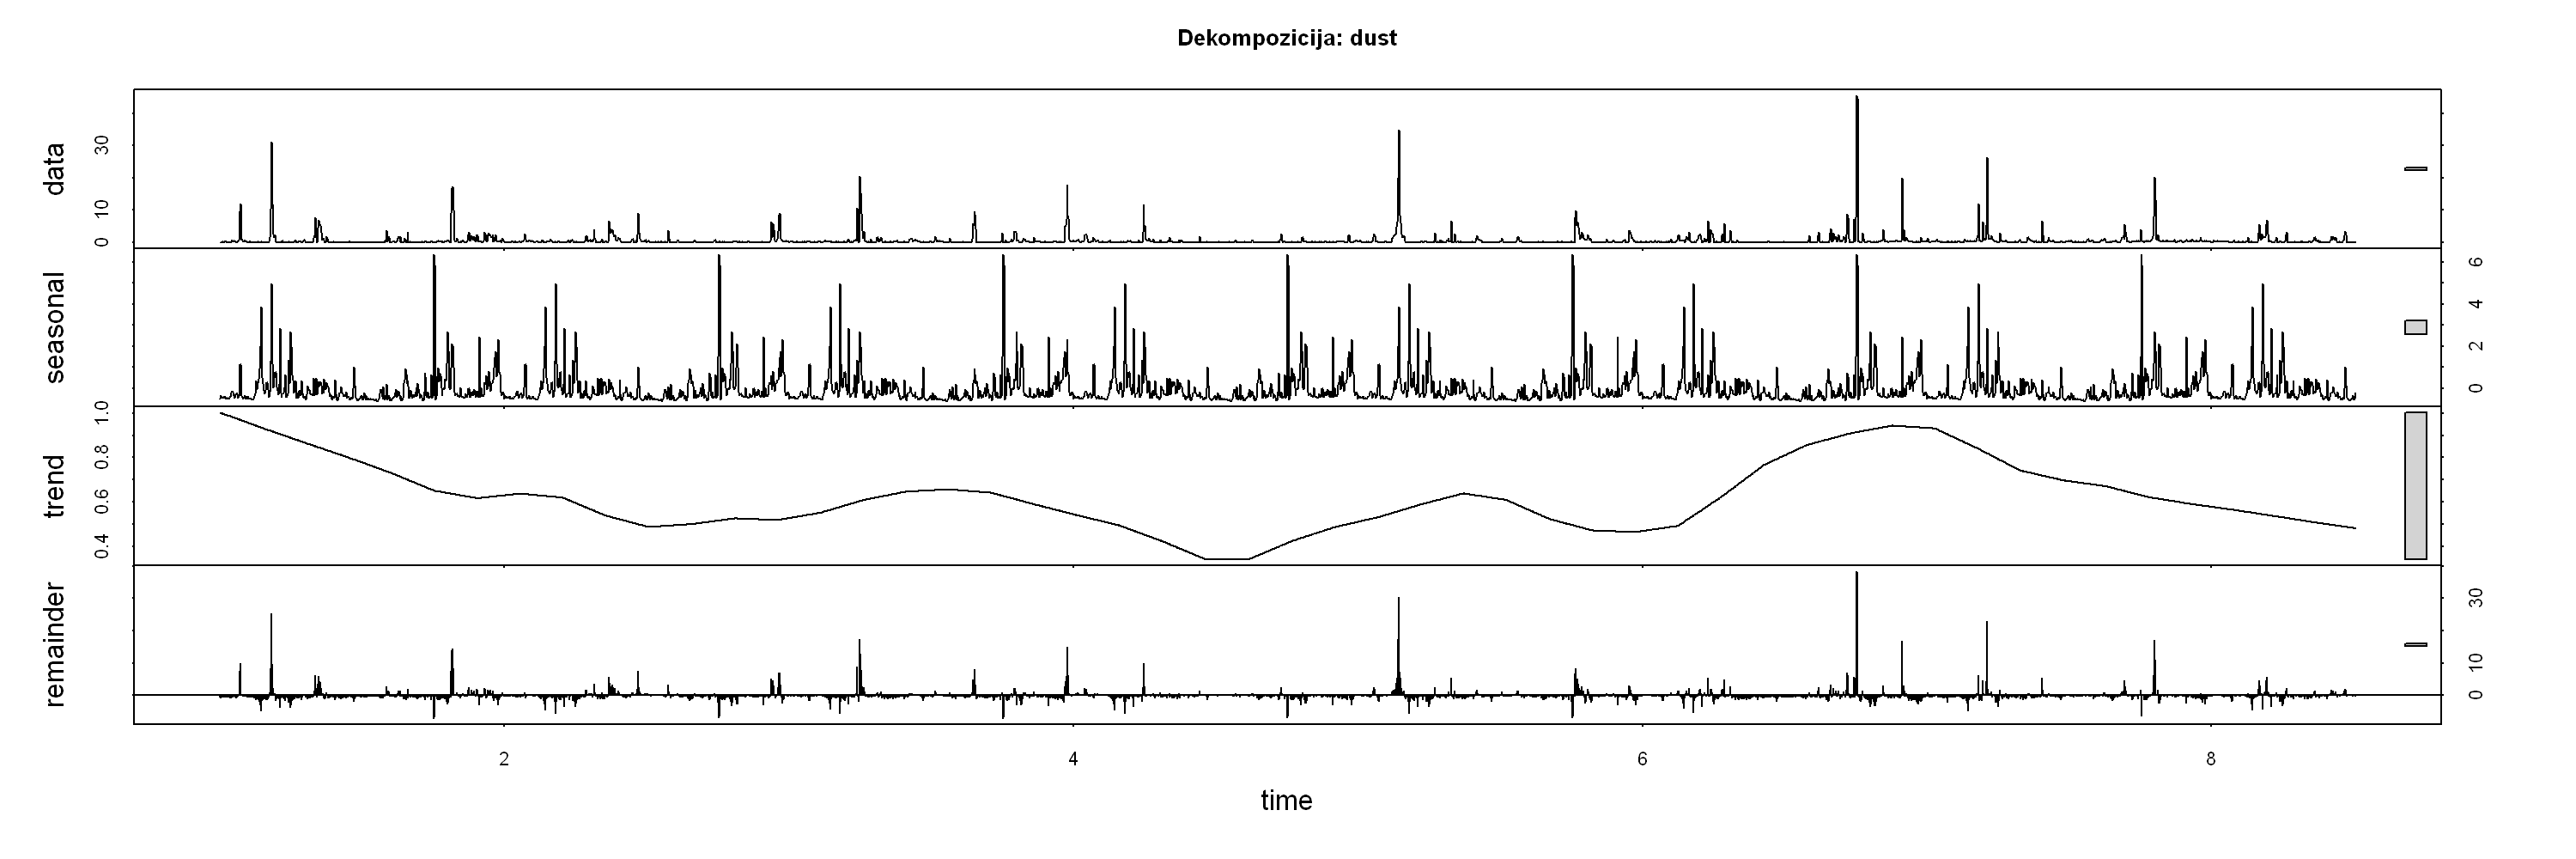

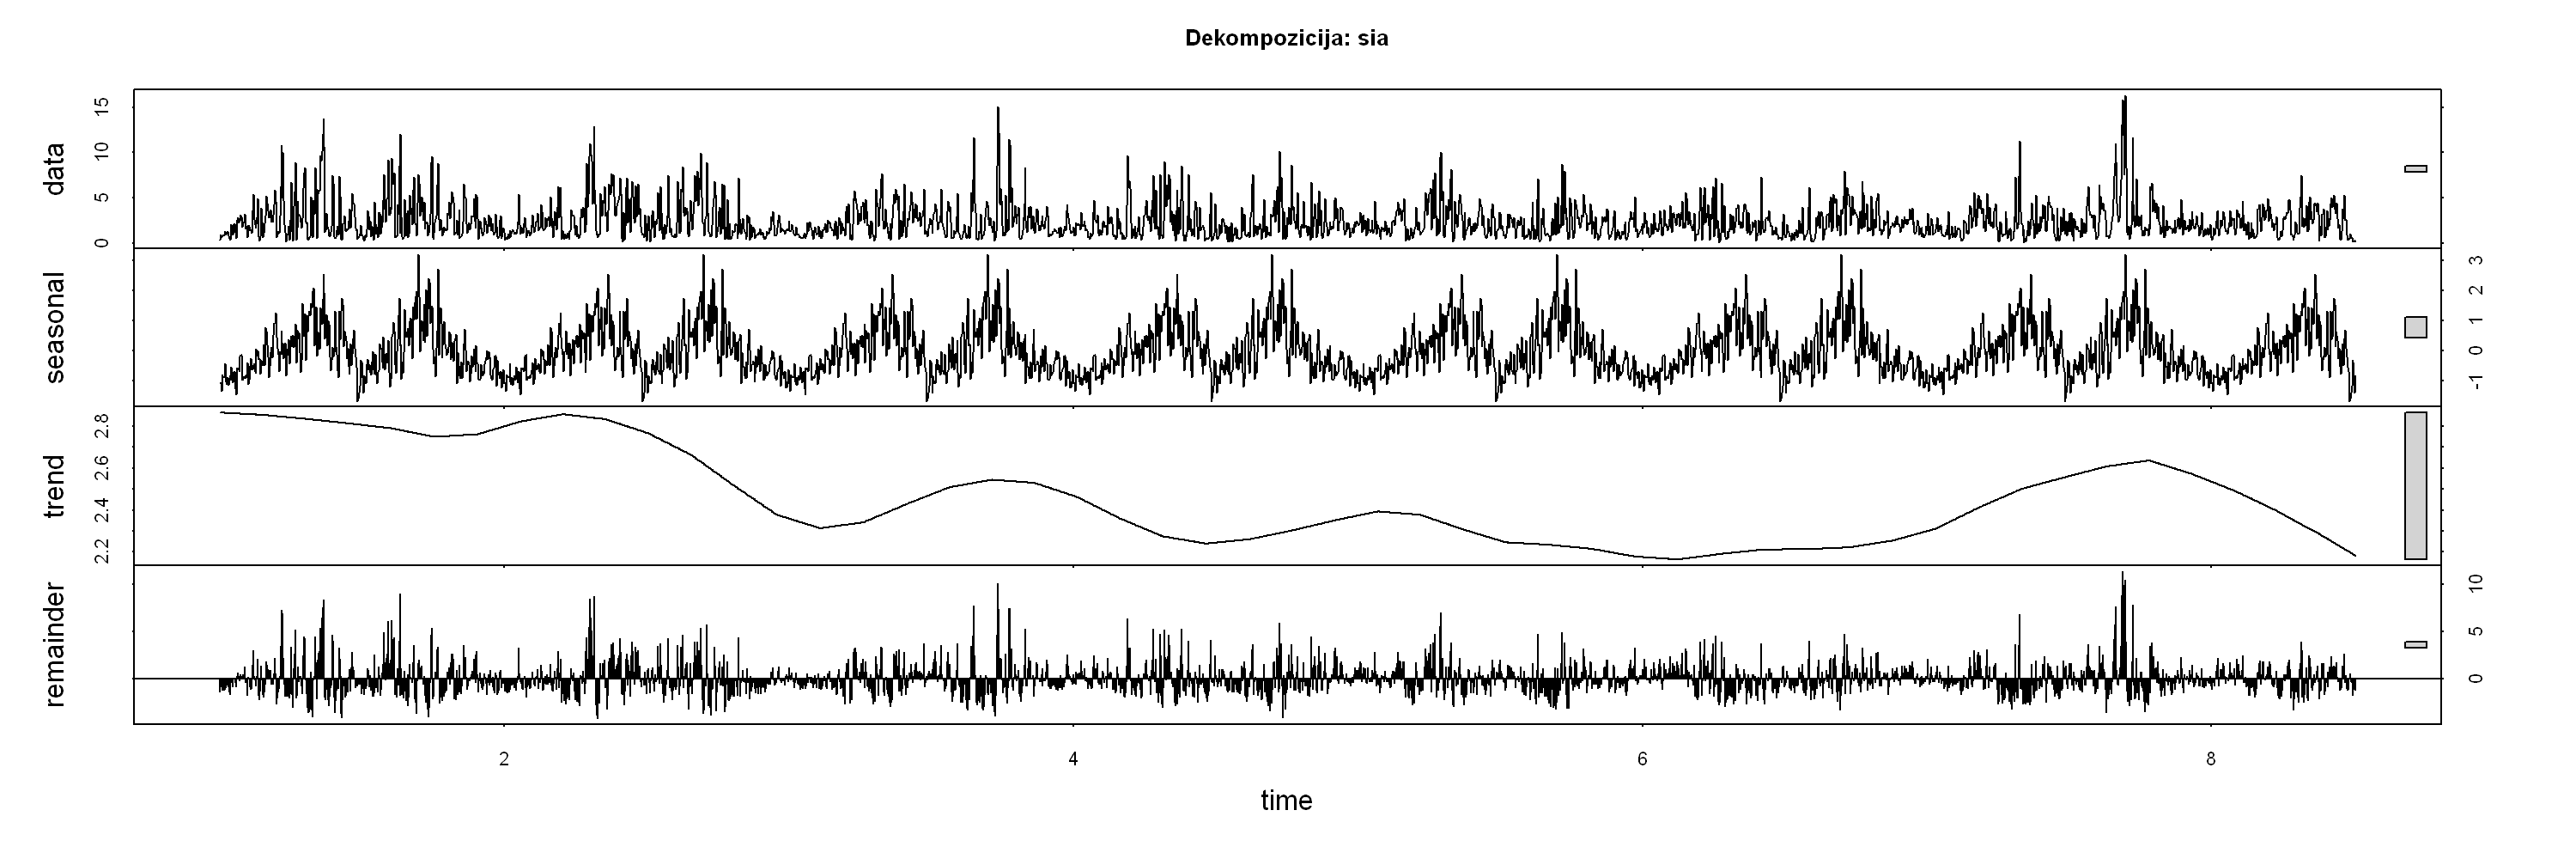

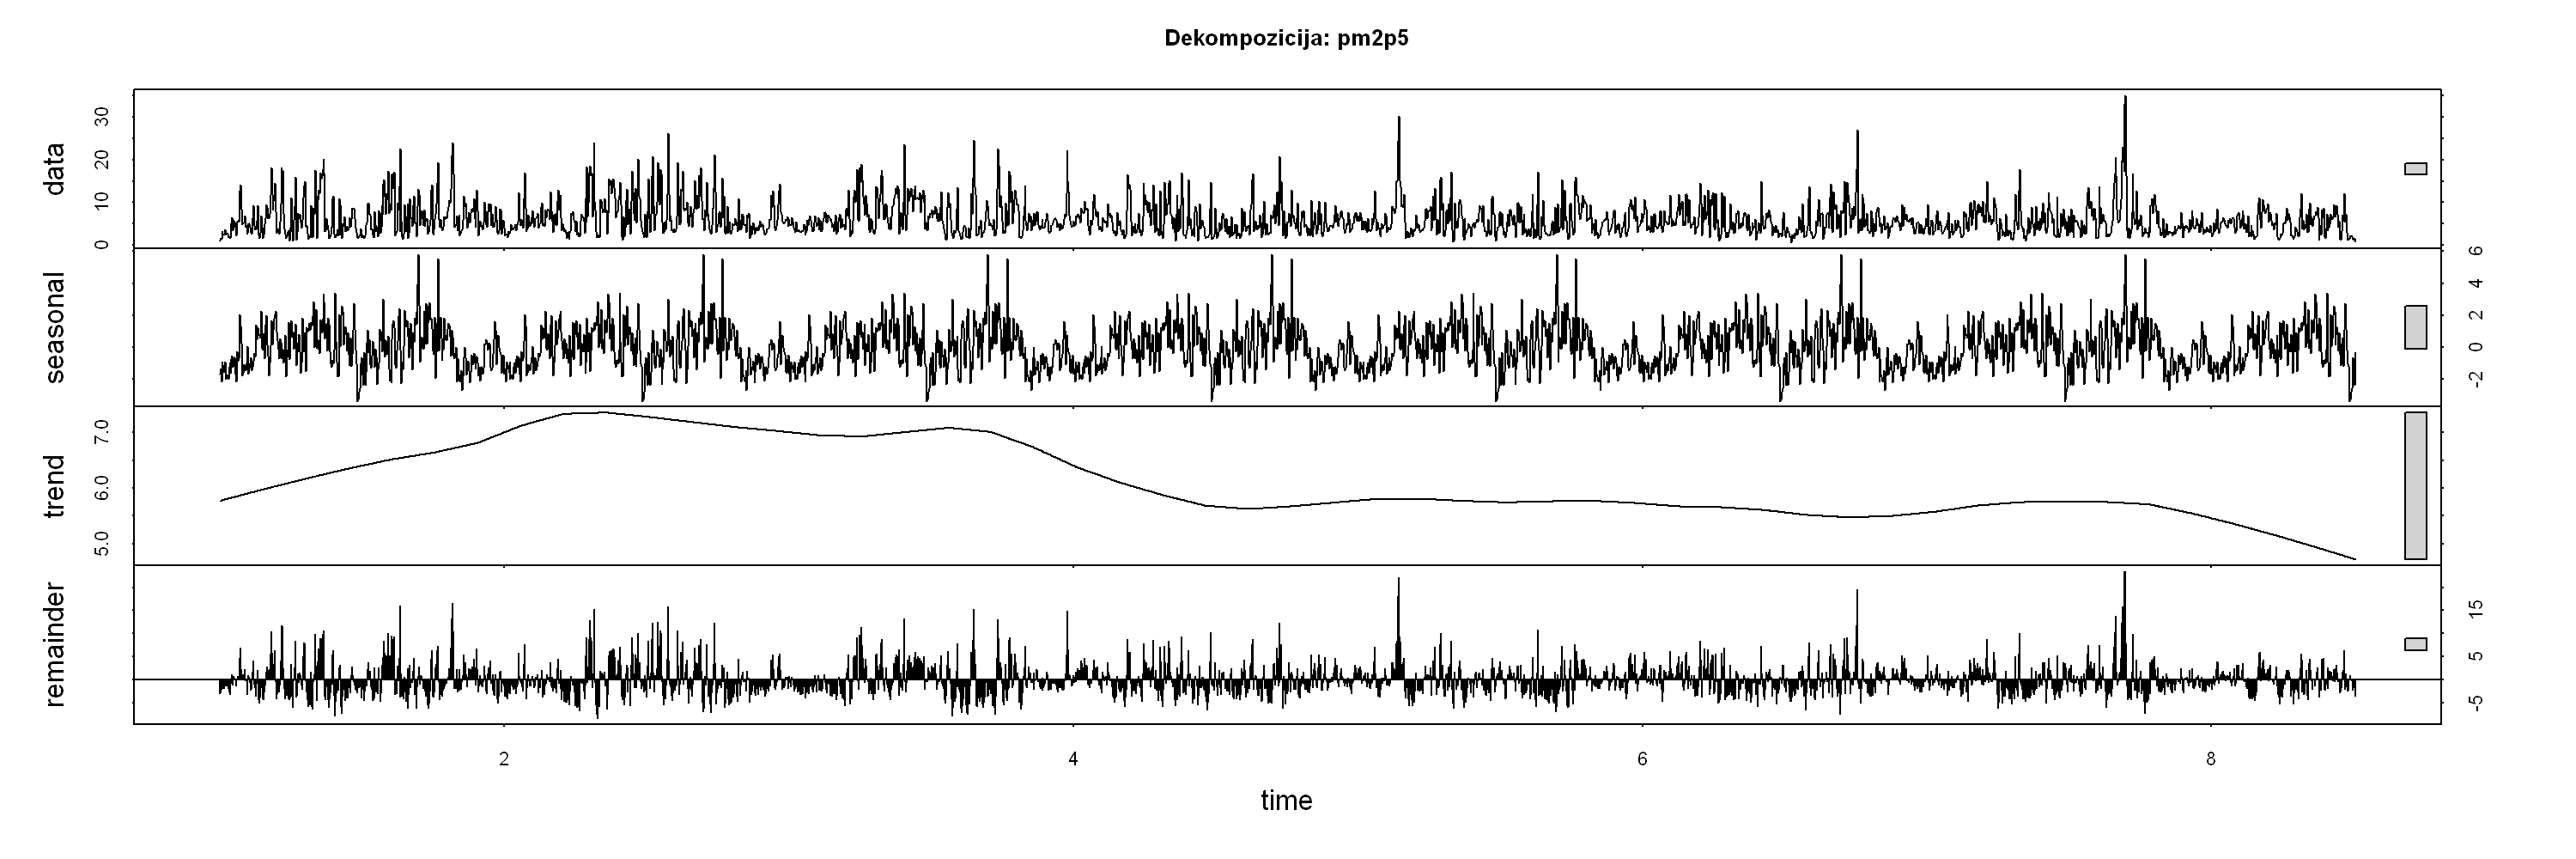

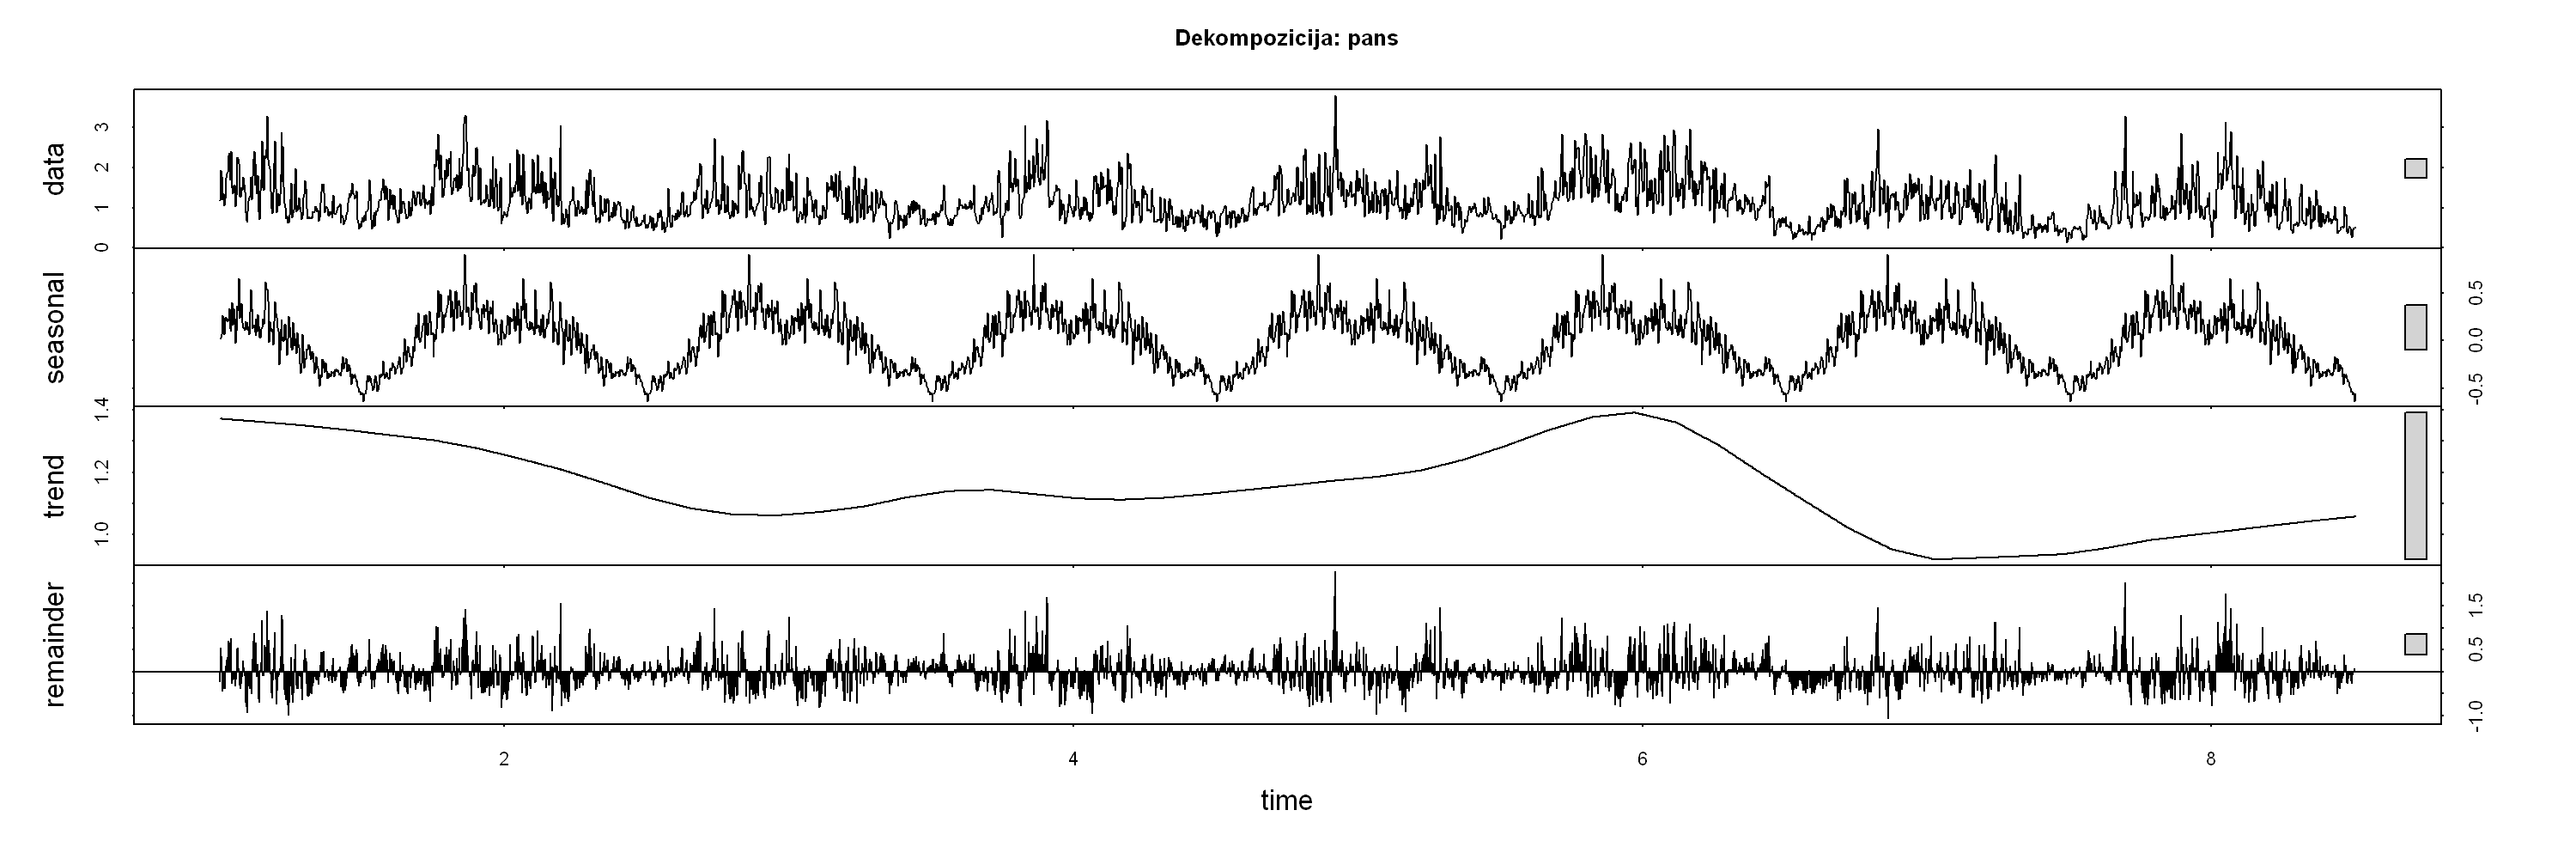

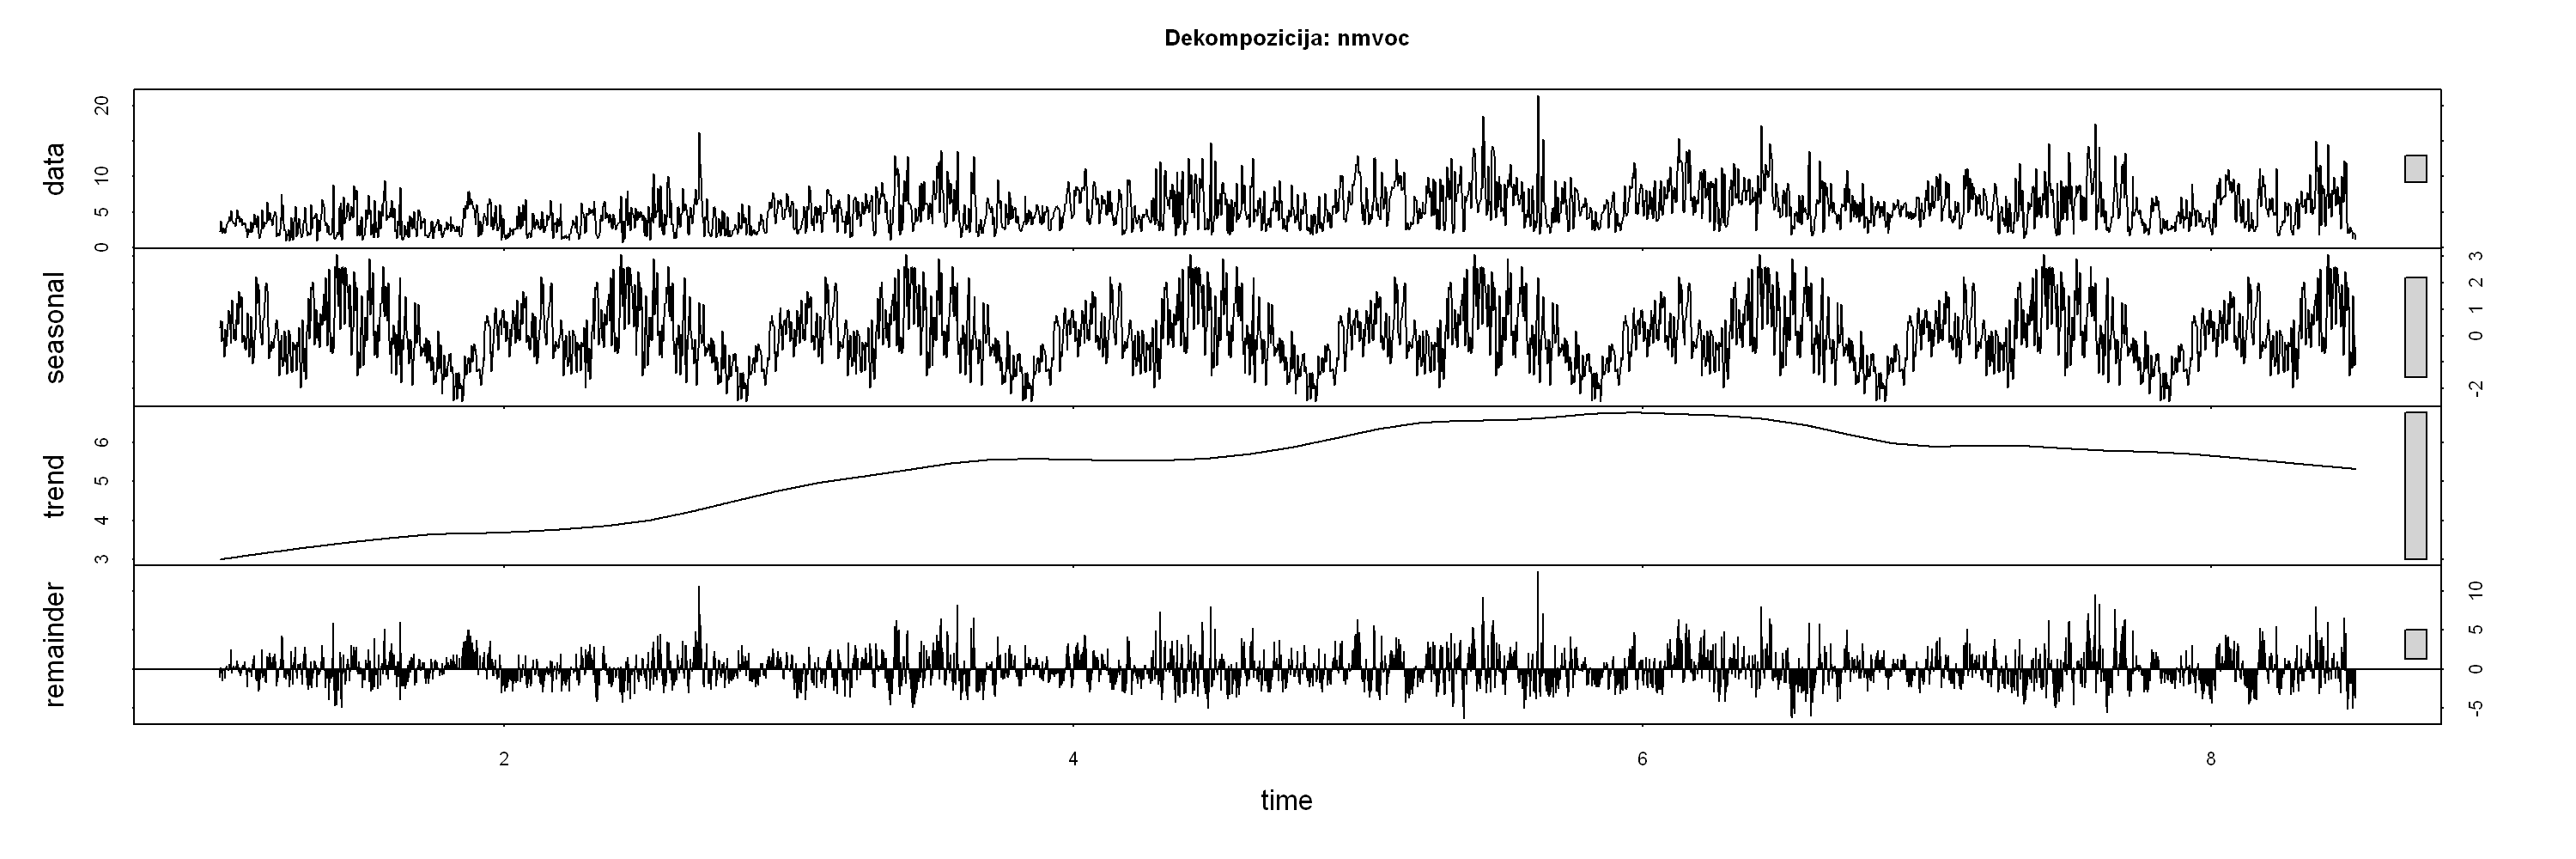

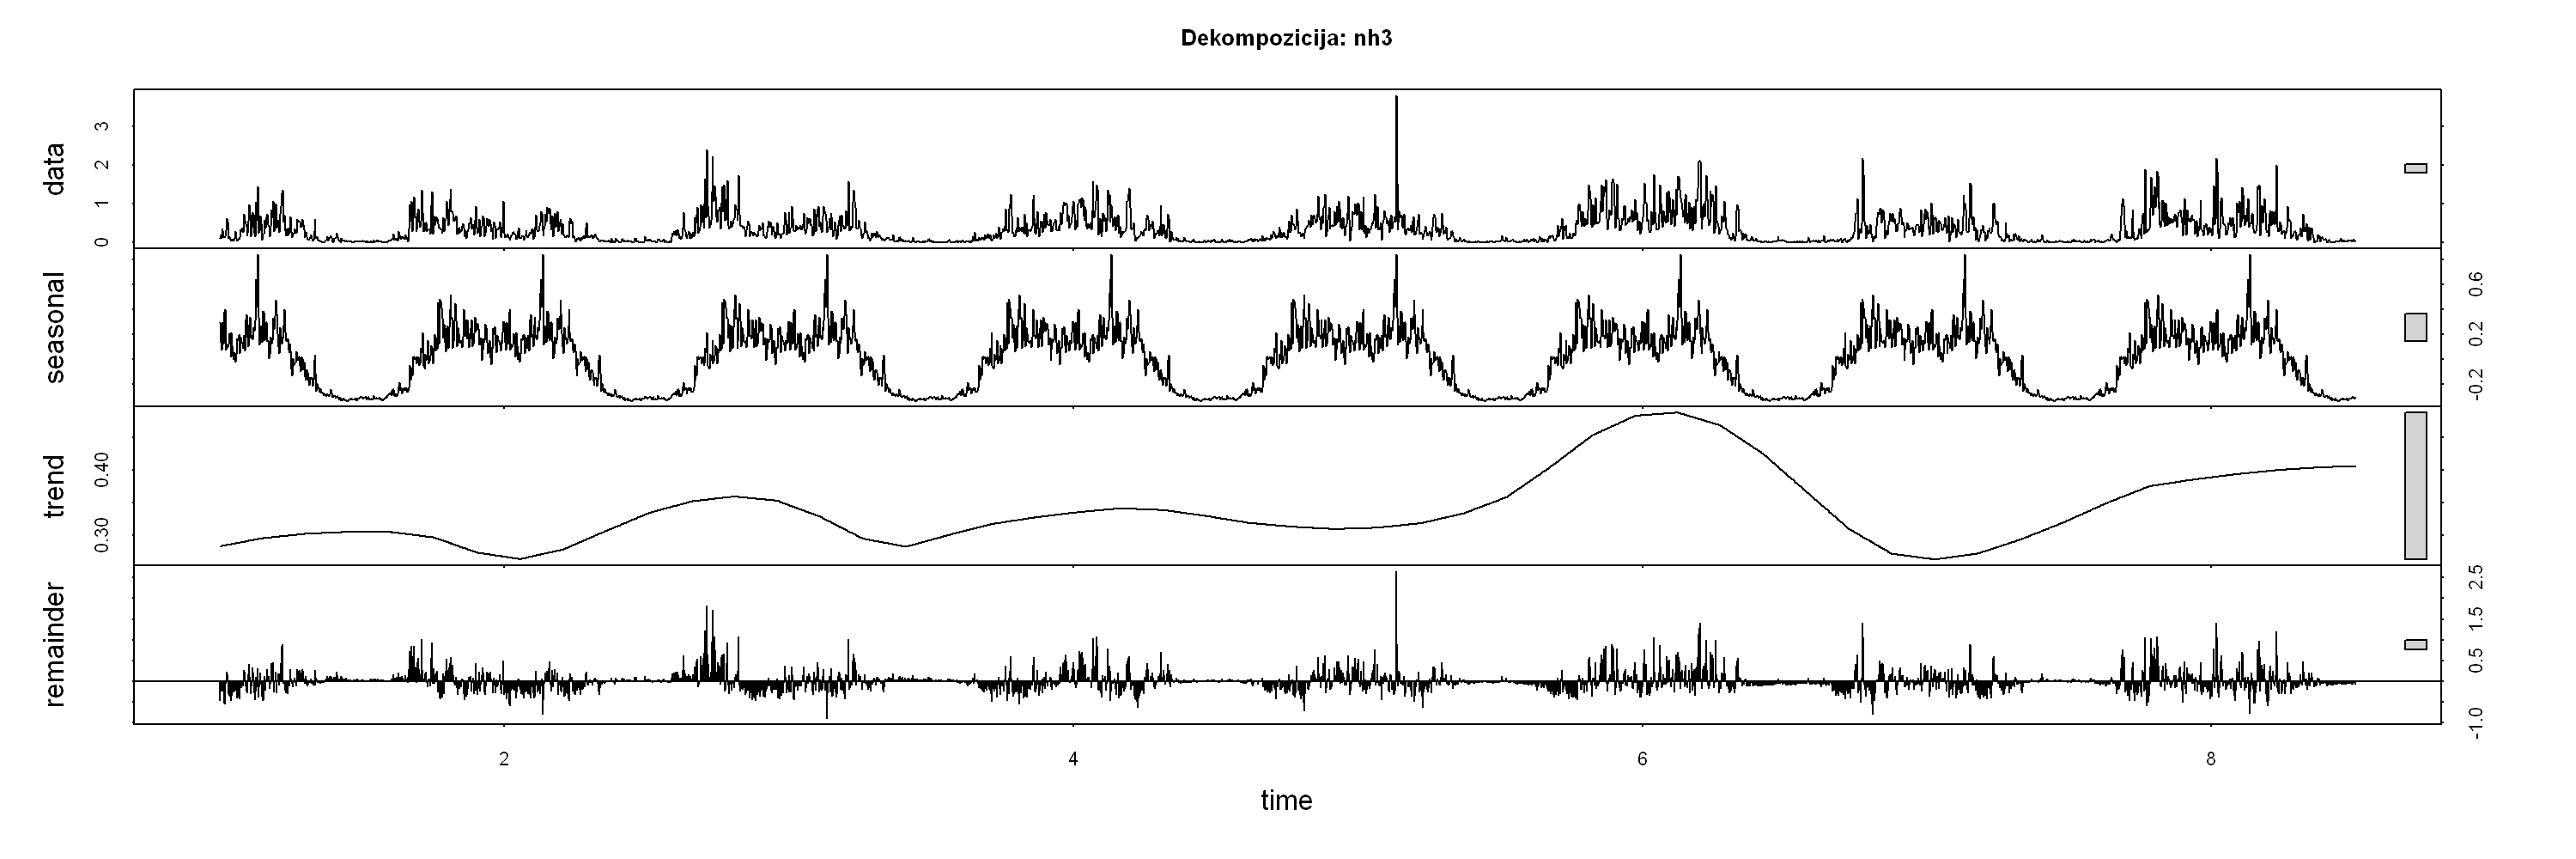

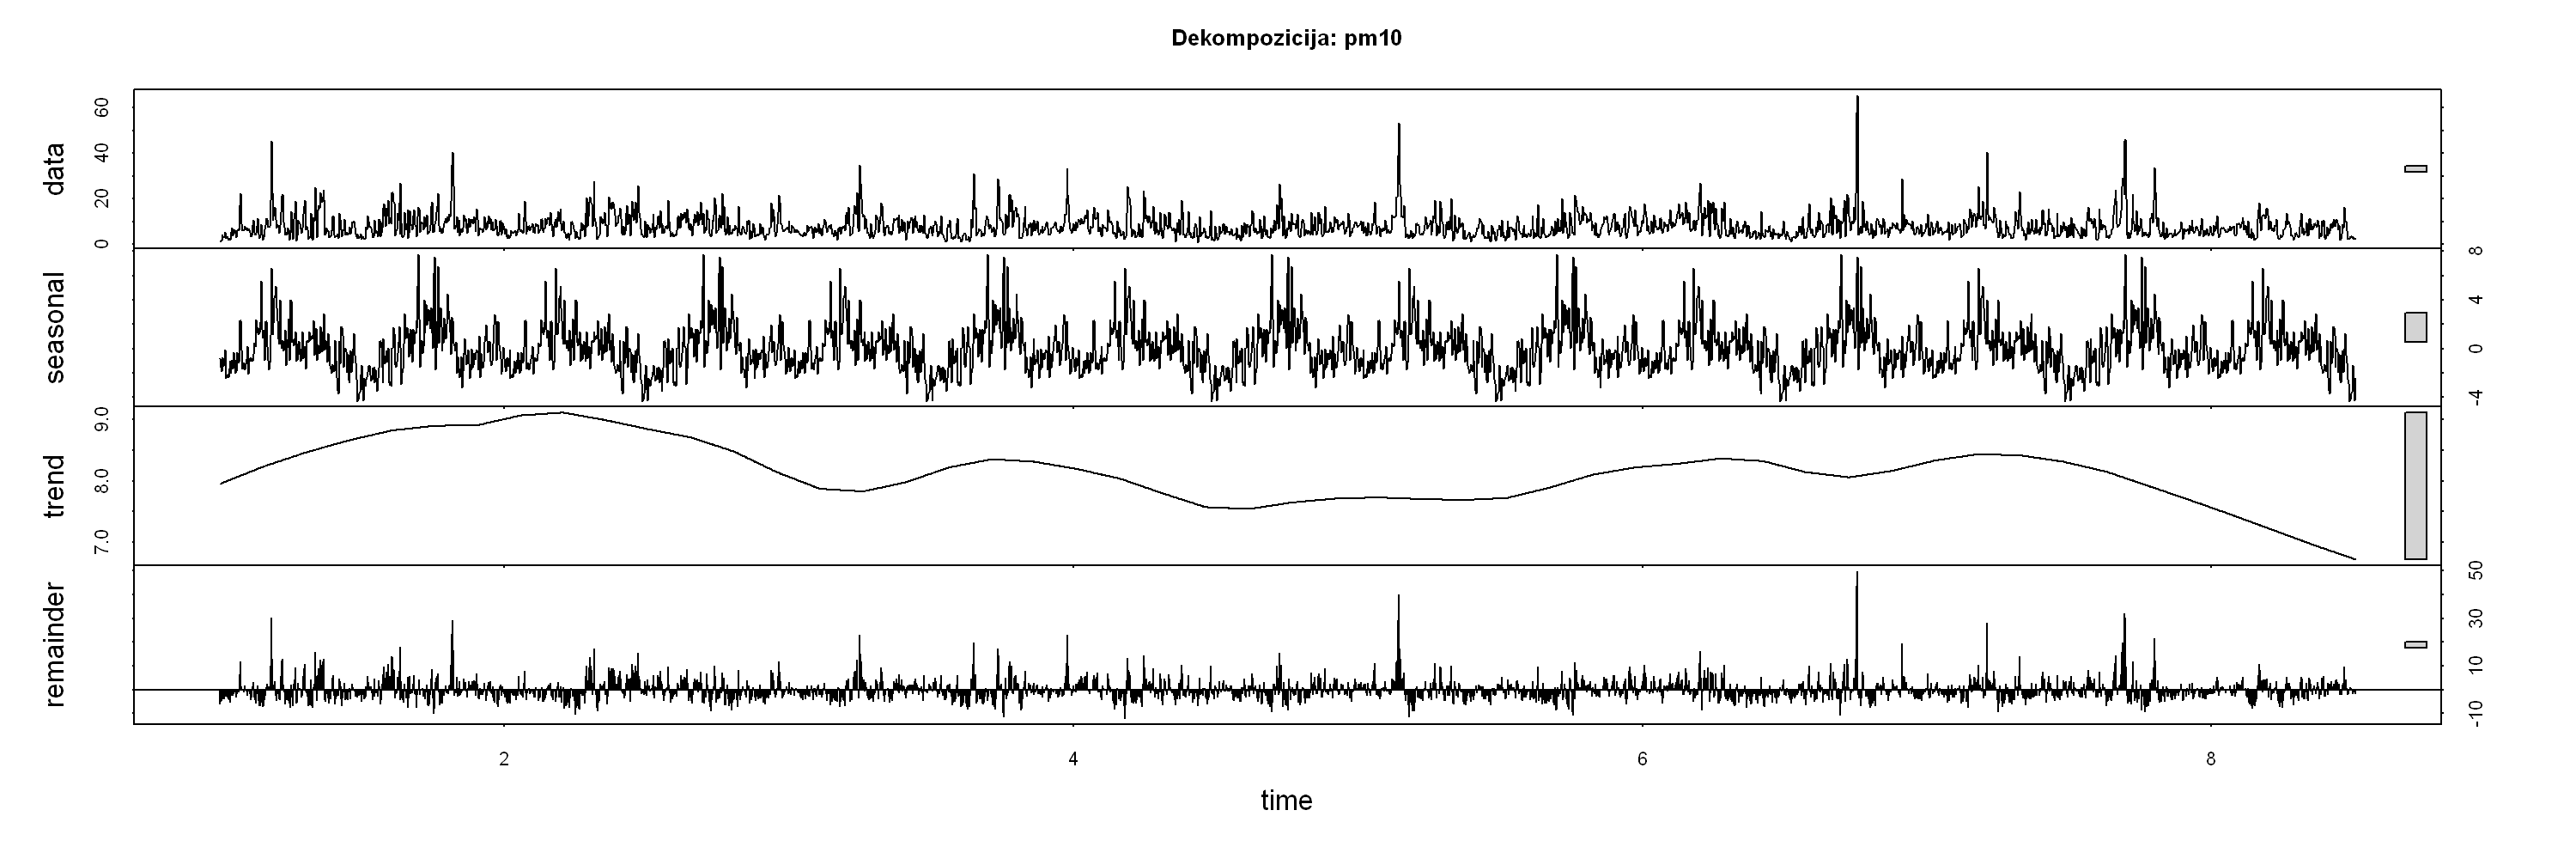

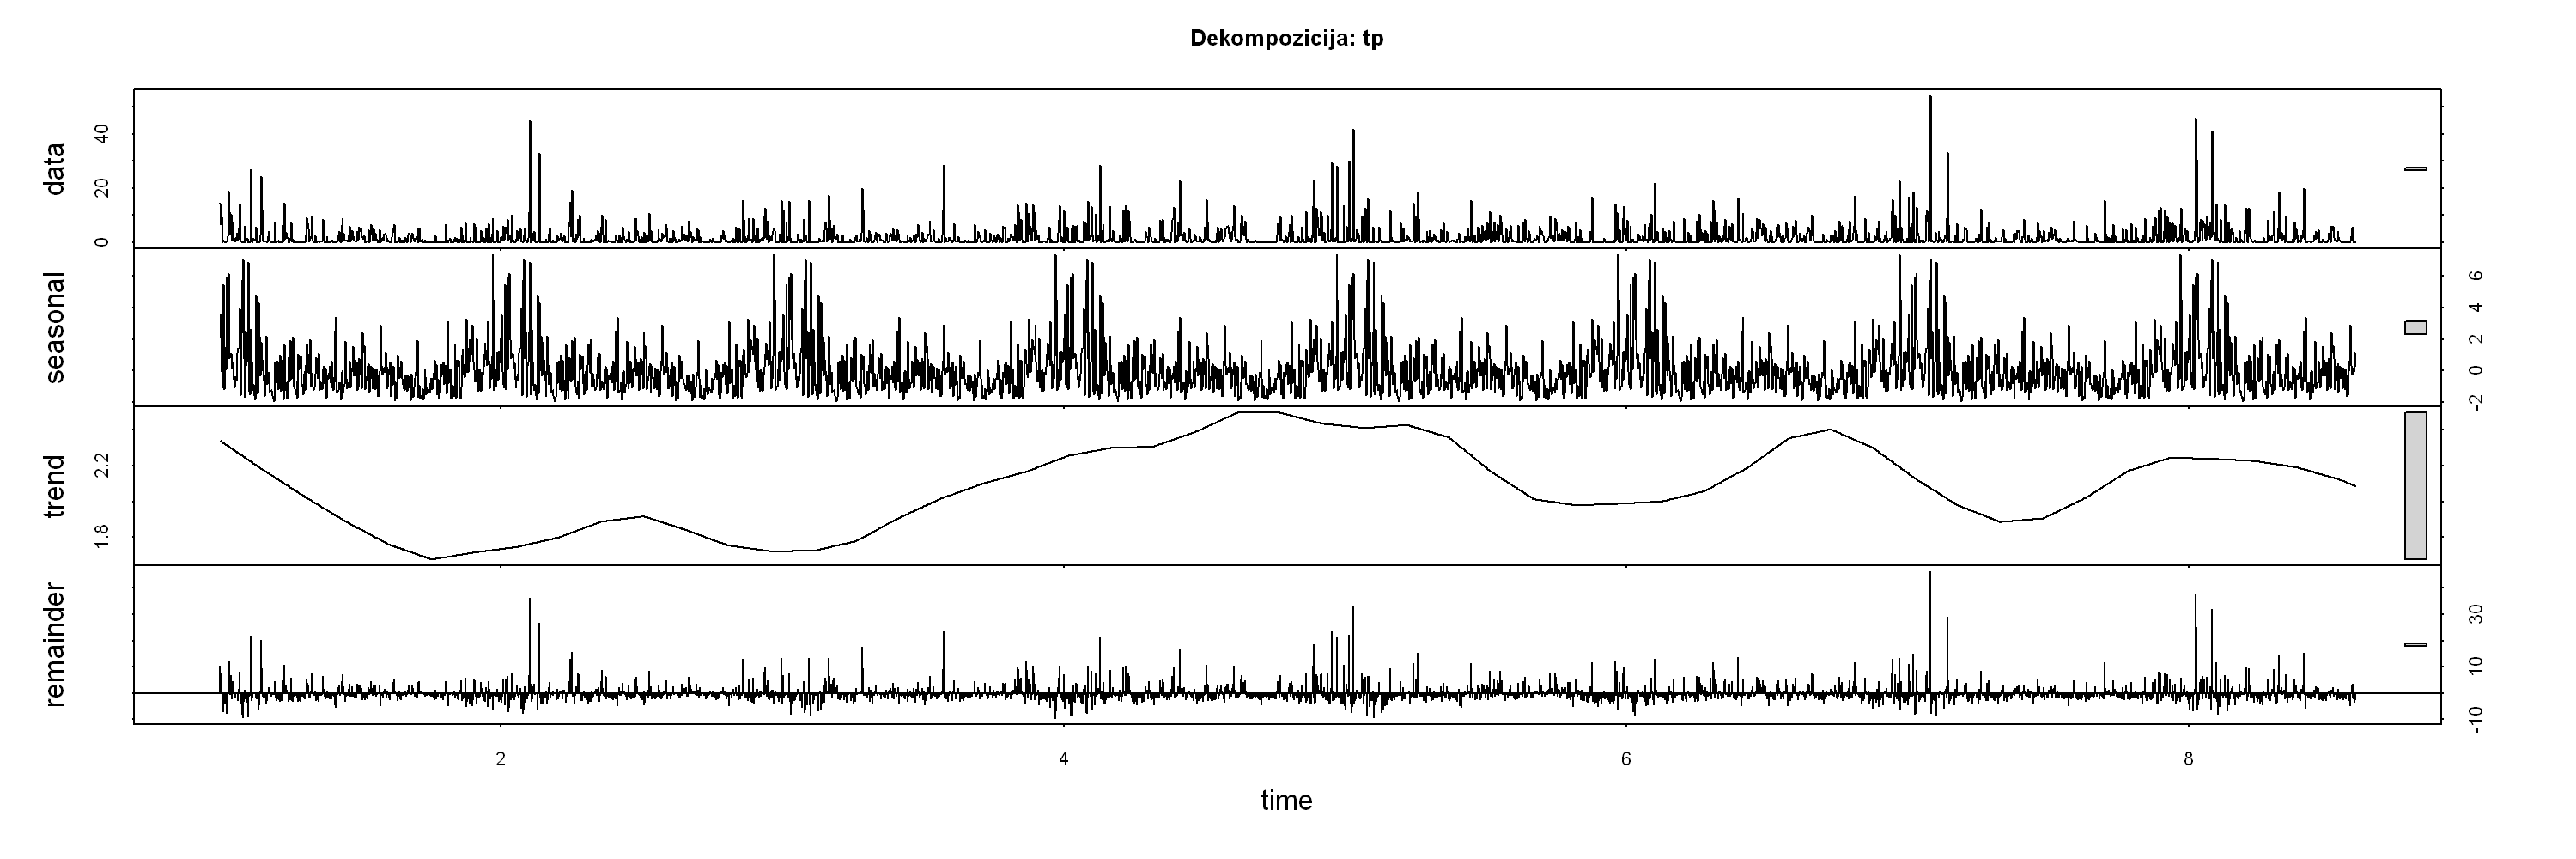

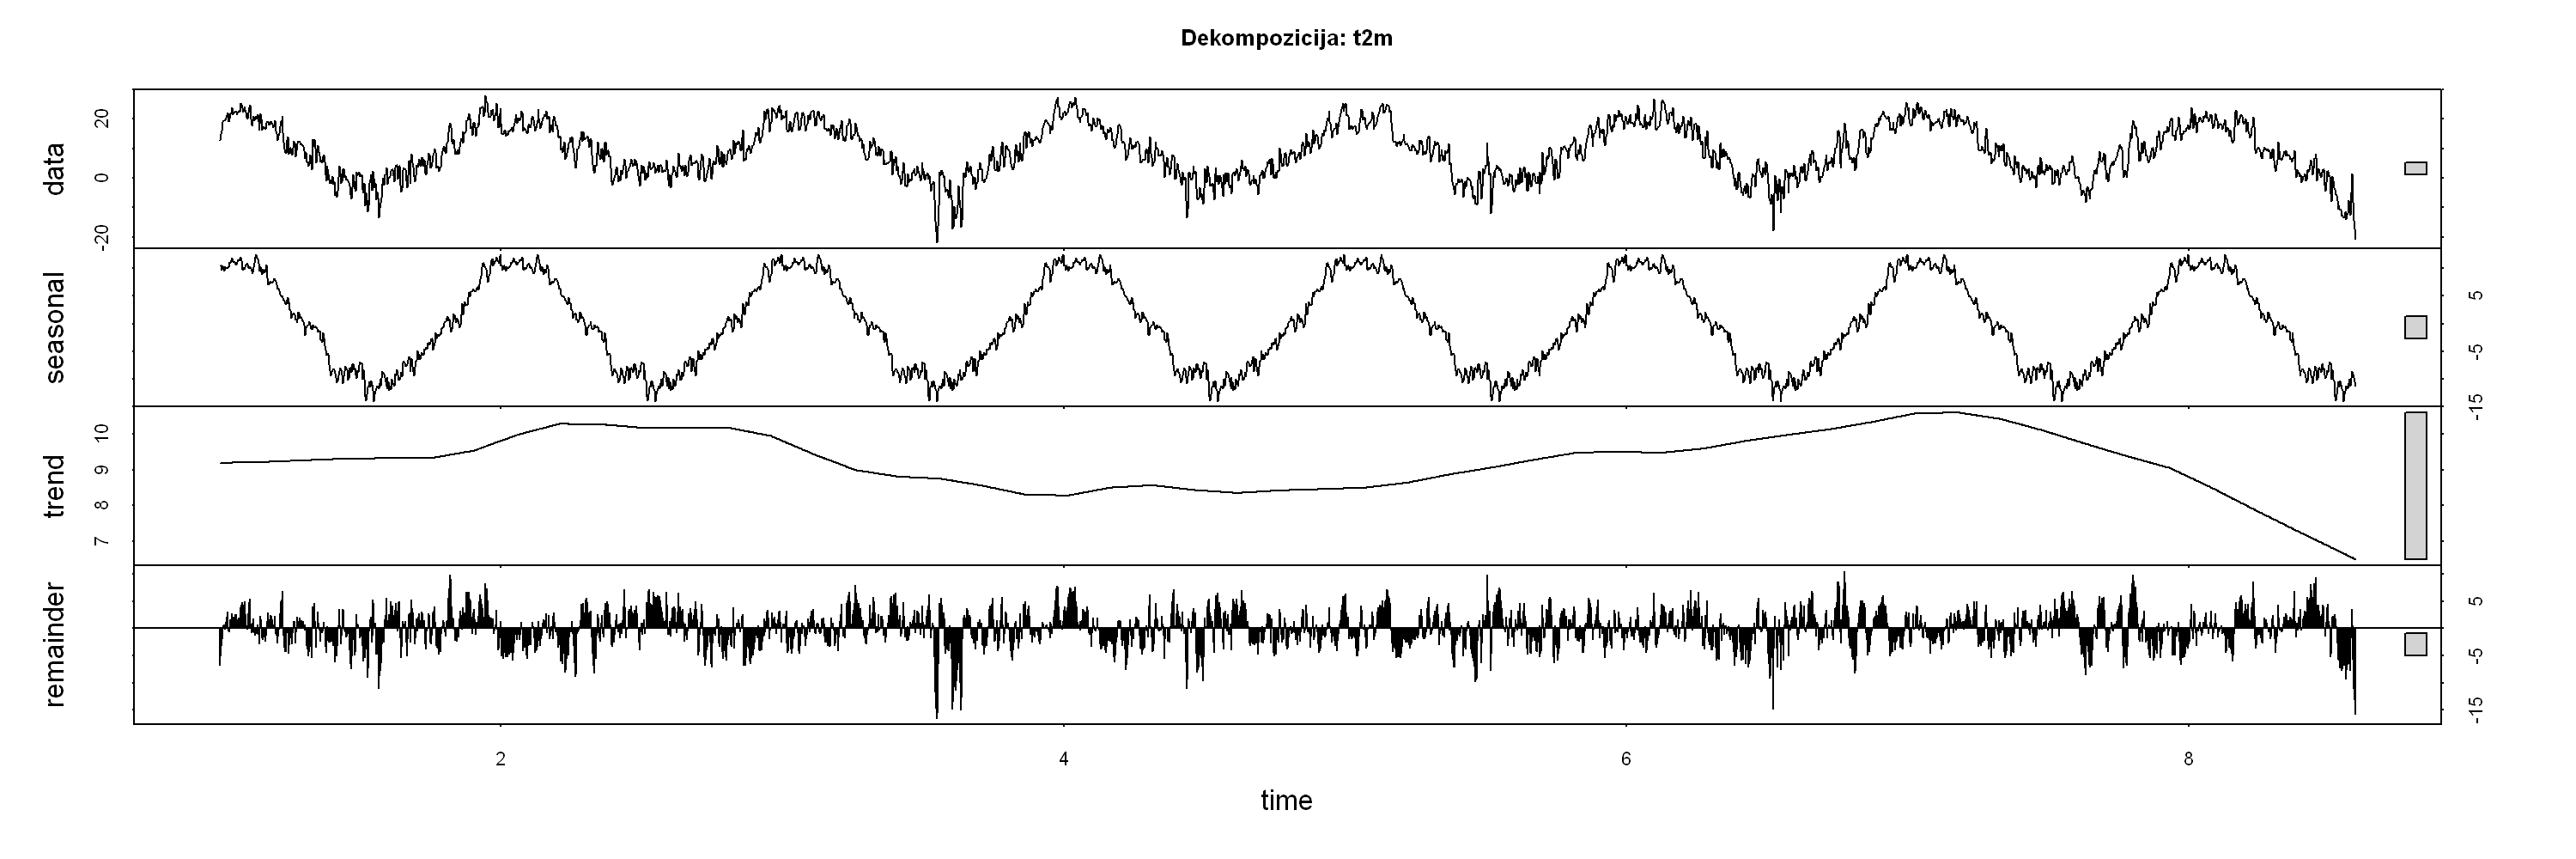

In [8]:
col_names <- colnames(data_clean)

for (name in col_names) {    
    if (name == "time") next

    plot(stl(ts(na.omit(data_clean[[name]]), frequency = 365), s.window = "periodic"), main = paste("Dekompozicija:", name))
}

In [ ]:
o tai jei 

In [9]:
# library(forecast)

# diff_summary <- data_clean %>%
#   select(where(is.numeric), -any_of("time")) %>%
#   summarise(across(everything(), list(ADF = ~ndiffs(., test = "adf", alpha = 0.05),
#                                       KPSS = ~ndiffs(., test = "kpss", alpha = 0.05)))) %>%
#   pivot_longer(everything(), names_to = c("Kintamasis", "Testas"), names_pattern = "(.*)_(ADF|KPSS)$", values_to = "ndiffs") %>%
#   pivot_wider(names_from = "Testas", values_from = "ndiffs")

# diff_summary

## Įvertinti oro taršos elementų įtaką orų rodiklių prognozavimo tikslumui

In [87]:
data_clean$ts_error <- abs(data_clean$xgb_precipitation - data_clean$tp)

In [89]:
x <- data_clean %>%
select(where(is.numeric)) %>%
select(-xgb_precipitation, -tp, -t2m, -ts_error)

cor_rez <- cor(x, data_clean$ts_error, use = "complete.obs", method = "spearman") 
cor_rez

airTemperature,0.0231191196
seaLevelPressure,-0.4291616680
relativeHumidity,0.2731733575
xgb_cloudCover,0.2822992828
feelsLikeTemperature_fixed,0.0088917156
windSpeed_fixed,0.1762326870
windGust_fixed,0.2238336054
windDirection_fixed,-0.0104577476
absorbing_aerosol_index,-0.0757083399
NO2_column_number_density,0.1395588396
stratospheric_NO2_column_number_density,0.0149481693


In [84]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)

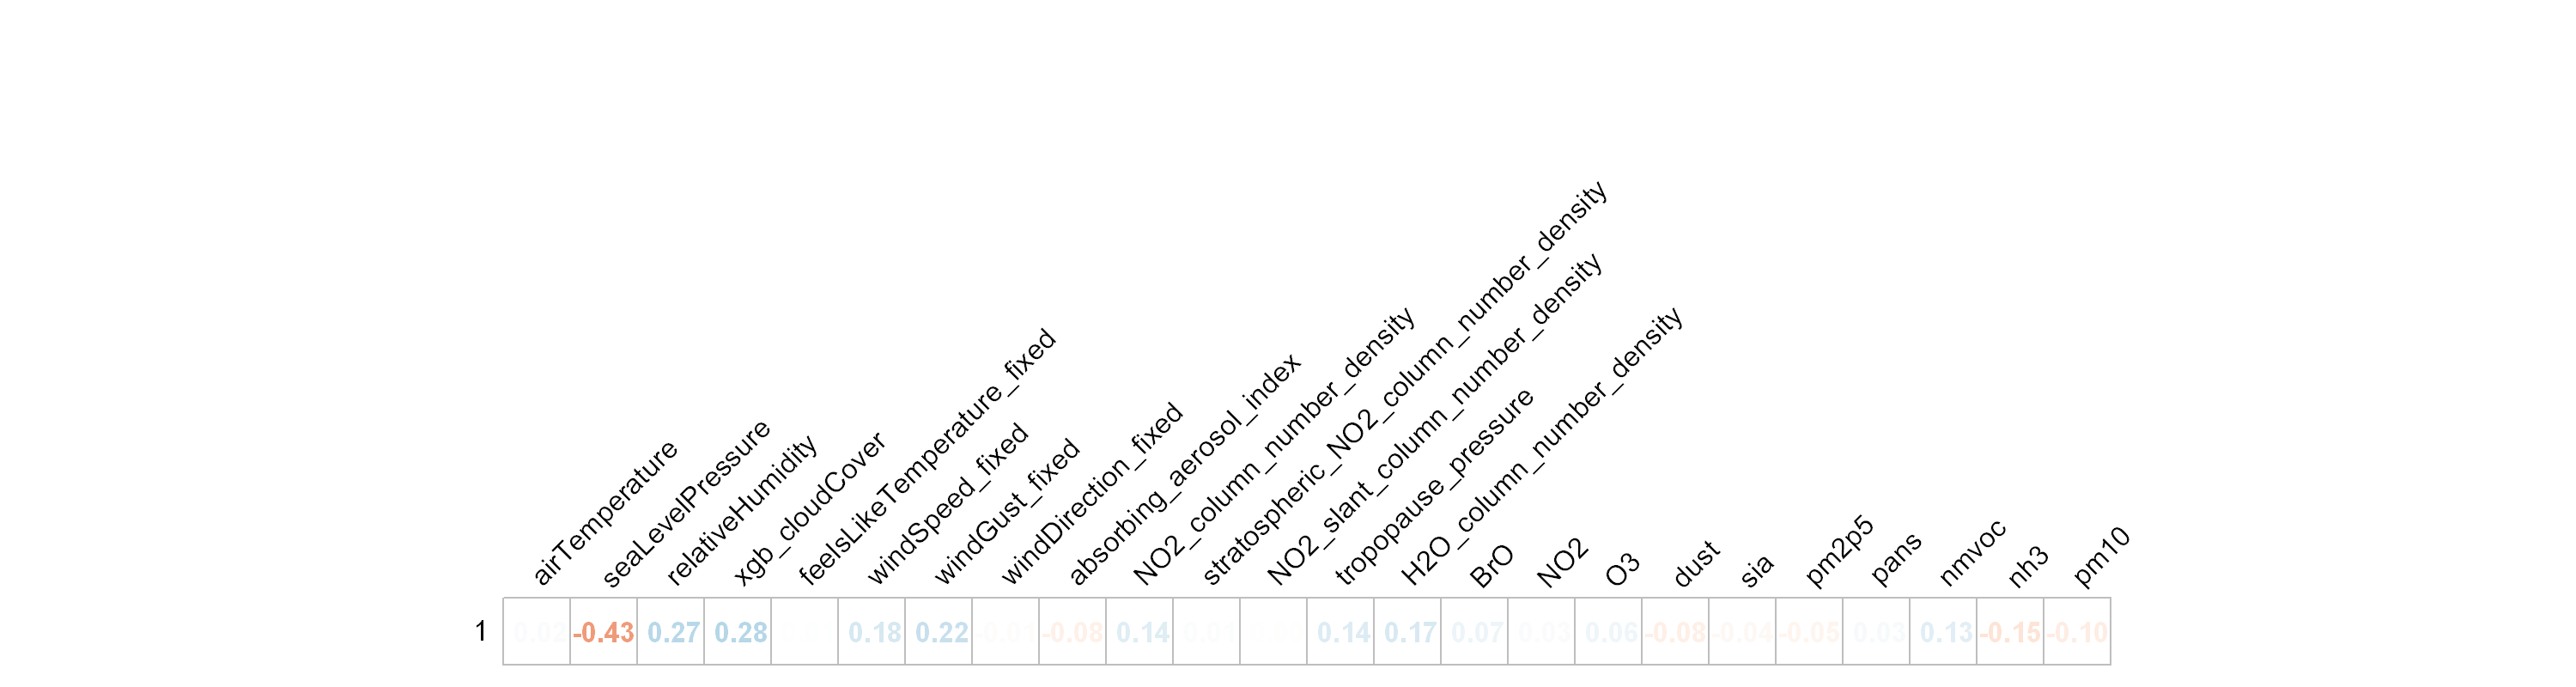

In [90]:
corrplot(t(cor_rez), method = 'number', tl.srt = 45, tl.col = 'black', cl.pos = 'n')

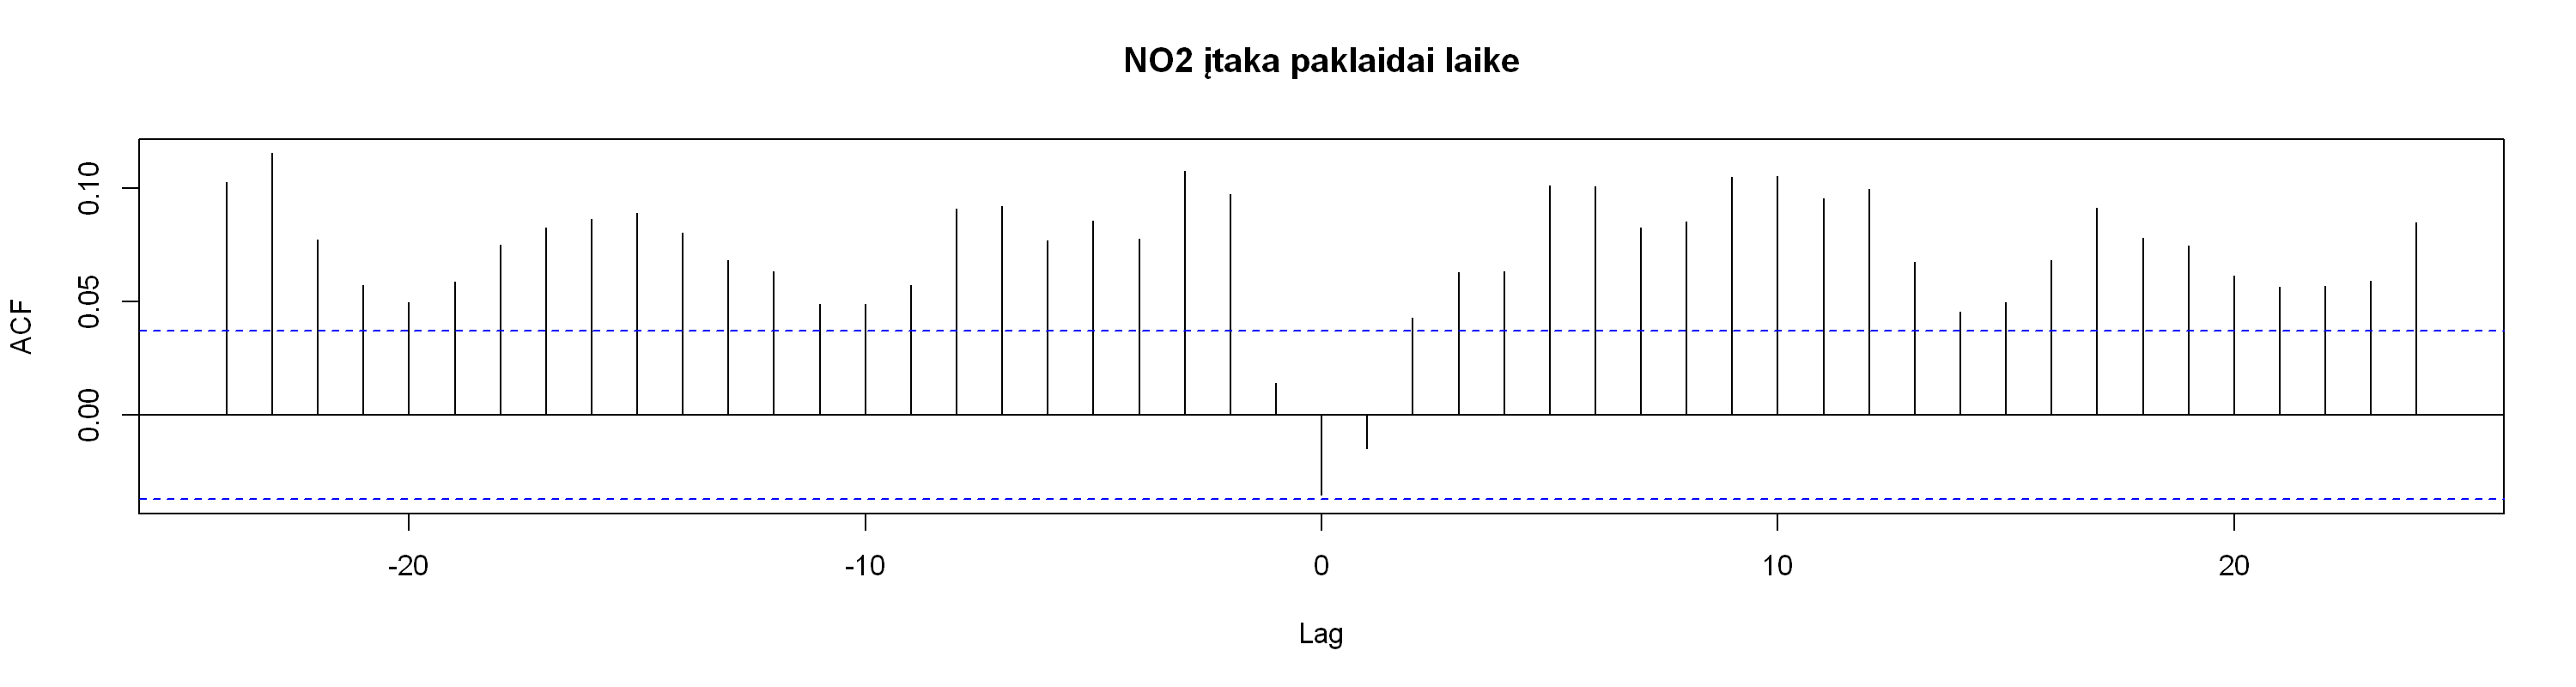

In [94]:
ccf(data_clean$nh3, data_clean$ts_error, lag.max = 24, na.action = na.pass, main = "NO2 įtaka paklaidai laike")

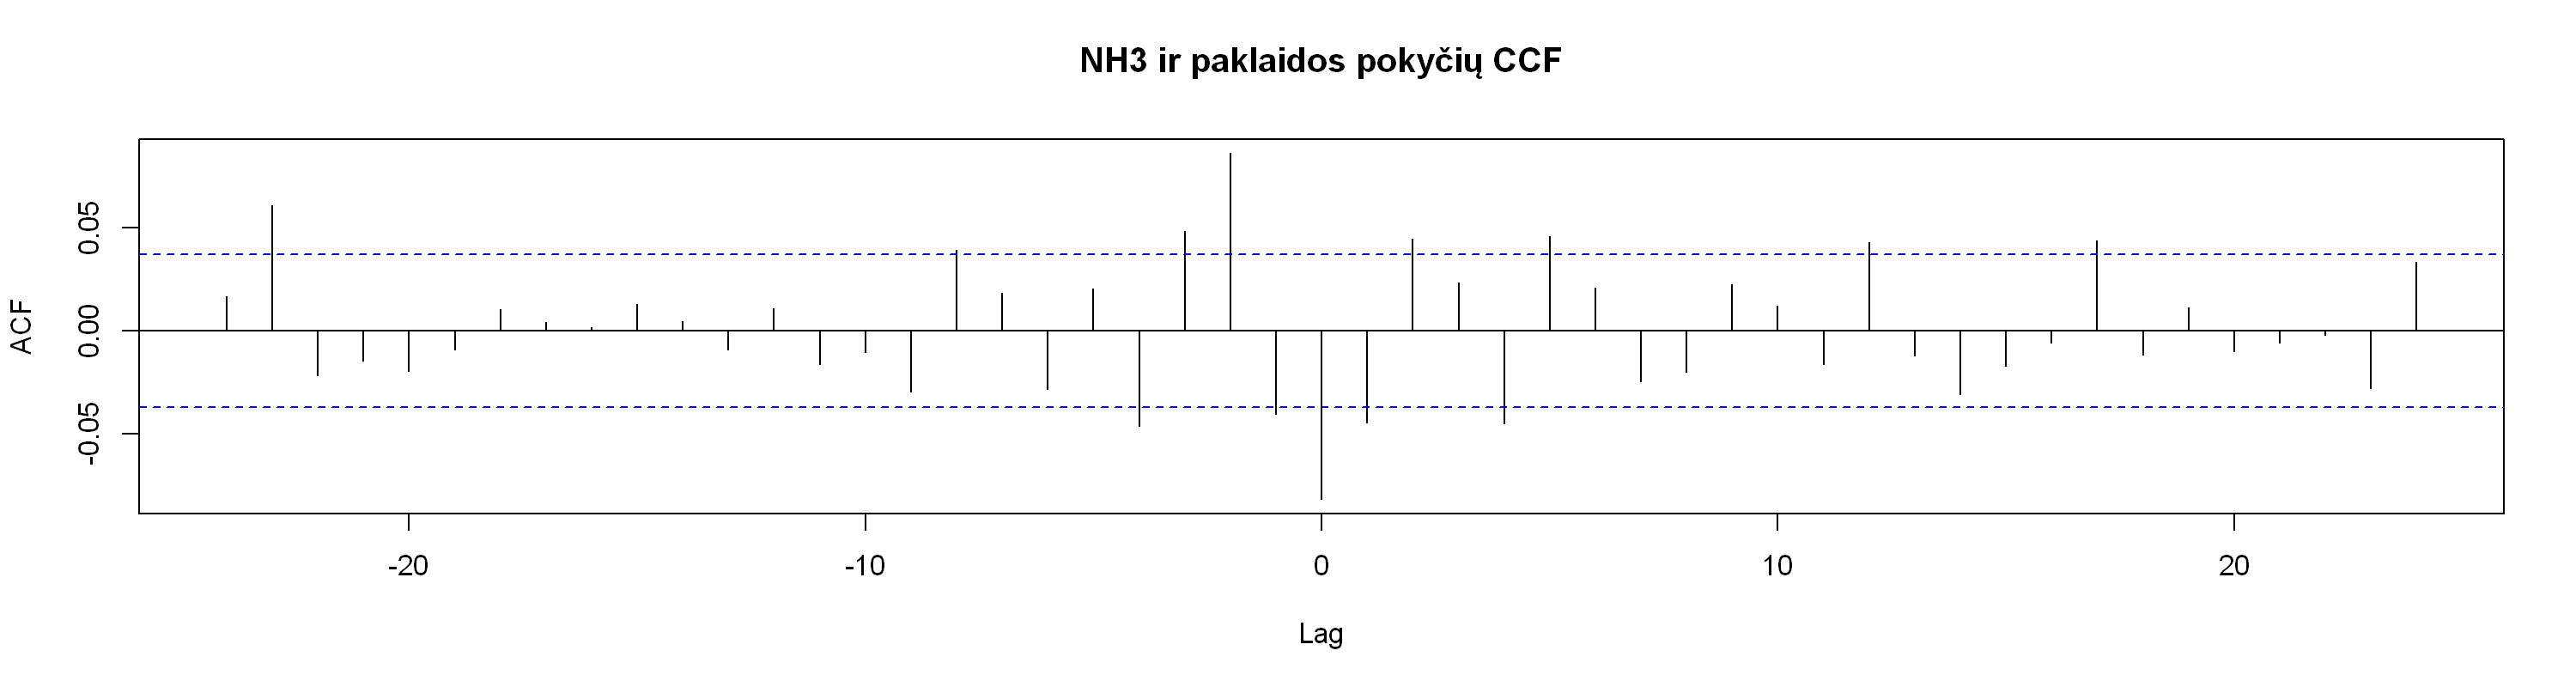

In [95]:
# Apskaičiuojame skirtumus (pirmąją eilutę paliekame NA)
nh3_diff <- diff(data_clean$nh3)
error_diff <- diff(data_clean$ts_error)

# CCF su diferencijuotais duomenimis
ccf(nh3_diff, error_diff, lag.max = 24, na.action = na.pass, 
    main = "NH3 ir paklaidos pokyčių CCF")